In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import networkx as nx
import lingam
import subprocess
import lingam
# import warnings

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from typing import Dict
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from lingam import VARLiNGAM, DirectLiNGAM
from causallearn.search.ConstraintBased.PC import pc





from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report
)

# warnings.filterwarnings('ignore')

# import warnings
# warnings.filterwarnings('ignore')


In [2]:
# Get all CSV files from the ../../data/machines folder
csv_files = glob.glob('../../data/azure_pm/machines/*.csv')

# Read each CSV file and create dataframes with the same name as the file
for file_path in csv_files:
    # Extract filename without extension
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    
    # Read CSV and assign to variable with the same name as the file
    globals()[file_name] = pd.read_csv(file_path)
    
    print(f"Loaded {file_name}.csv with shape: {globals()[file_name].shape}")

Loaded machine_1.csv with shape: (8772, 11)
Loaded machine_10.csv with shape: (8775, 11)
Loaded machine_100.csv with shape: (8766, 11)
Loaded machine_11.csv with shape: (8771, 11)
Loaded machine_12.csv with shape: (8773, 11)
Loaded machine_13.csv with shape: (8781, 11)
Loaded machine_14.csv with shape: (8772, 11)
Loaded machine_15.csv with shape: (8775, 11)
Loaded machine_16.csv with shape: (8773, 11)
Loaded machine_17.csv with shape: (8778, 11)
Loaded machine_18.csv with shape: (8770, 11)
Loaded machine_19.csv with shape: (8769, 11)
Loaded machine_2.csv with shape: (8773, 11)
Loaded machine_20.csv with shape: (8771, 11)
Loaded machine_21.csv with shape: (8773, 11)
Loaded machine_22.csv with shape: (8778, 11)
Loaded machine_23.csv with shape: (8771, 11)
Loaded machine_24.csv with shape: (8771, 11)
Loaded machine_25.csv with shape: (8777, 11)
Loaded machine_26.csv with shape: (8772, 11)
Loaded machine_27.csv with shape: (8775, 11)
Loaded machine_28.csv with shape: (8769, 11)
Loaded mach

In [3]:
machine_1.head()

,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,failure
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,0,0,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,0,0,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18,0,0,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18,0,0,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,model3,18,0,0,0


<br> <br>

## Data Encoding and Scaling

In [4]:
def encode_and_scale_dataframe(df, target_column='failure', categorical_cols=['model'], numerical_cols=['age', 'volt', 'pressure', 'vibration'], scaling_method='standard', exclude_features=None, remove_excluded=False):
  
    # Handle exclude_features parameter
    if exclude_features is None:
        exclude_features = []
    elif isinstance(exclude_features, str):
        exclude_features = [exclude_features]
    
    # Create a copy to avoid modifying original dataframe
    df_processed = df.copy()
    
    print("🔄 Starting encoding and scaling process...")
    print(f"📊 Original dataframe shape: {df_processed.shape}")
    
    if exclude_features:
        print(f"🚫 Excluding features from processing: {exclude_features}")
        if remove_excluded:
            print(f"🗑️  Features will be removed from output dataframe")
    
    # Dictionary to store encoders for later use
    encoders = {}
    
    # 1. ENCODE CATEGORICAL VARIABLES
    print("\n1️⃣ ENCODING CATEGORICAL VARIABLES")
    print("-" * 40)
    
    # Filter out excluded features from categorical columns
    categorical_cols_to_process = [col for col in categorical_cols if col not in exclude_features]
    excluded_categorical = [col for col in categorical_cols if col in exclude_features]
    
    if excluded_categorical:
        print(f"   🚫 Skipping categorical encoding for: {excluded_categorical}")
    
    for col in categorical_cols_to_process:
        if col in df_processed.columns:
            print(f"   Encoding '{col}'...")
            
            # Create and fit label encoder
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            
            # Store encoder for future use
            encoders[col] = le
            
            # Display encoding mapping
            unique_values = df[col].unique()
            encoded_values = le.transform(unique_values.astype(str))
            mapping = dict(zip(unique_values, encoded_values))
            
            print(f"   ✅ {col} encoded: {mapping}")
        else:
            print(f"   ⚠️  Column '{col}' not found in dataframe")
    
    # 2. ENCODE TARGET VARIABLE (FAILURE)
    print(f"\n2️⃣ ENCODING TARGET VARIABLE: '{target_column}'")
    print("-" * 40)
    
    if target_column in exclude_features:
        print(f"   🚫 Skipping target variable encoding (excluded): '{target_column}'")
    elif target_column in df_processed.columns:
        print(f"   Encoding '{target_column}'...")
        
        # Check if target is already numeric
        if df_processed[target_column].dtype in ['object', 'category']:
            le_target = LabelEncoder()
            df_processed[target_column] = le_target.fit_transform(df_processed[target_column].astype(str))
            encoders[target_column] = le_target
            
            # Display target encoding mapping
            unique_targets = df[target_column].unique()
            encoded_targets = le_target.transform(unique_targets.astype(str))
            target_mapping = dict(zip(unique_targets, encoded_targets))
            print(f"   ✅ {target_column} encoded: {target_mapping}")
        else:
            print(f"   ℹ️  {target_column} is already numeric")
    else:
        print(f"   ⚠️  Target column '{target_column}' not found")
    
    # 3. SCALE NUMERICAL FEATURES
    print(f"\n3️⃣ SCALING NUMERICAL FEATURES ({scaling_method.upper()})")
    print("-" * 40)
    
    # Filter out excluded features from numerical columns
    numerical_cols_to_process = [col for col in numerical_cols if col not in exclude_features]
    excluded_numerical = [col for col in numerical_cols if col in exclude_features]
    
    if excluded_numerical:
        print(f"   🚫 Skipping scaling for: {excluded_numerical}")
    
    # Filter numerical columns that exist in dataframe
    existing_numerical_cols = [col for col in numerical_cols_to_process if col in df_processed.columns]
    missing_numerical_cols = [col for col in numerical_cols_to_process if col not in df_processed.columns]
    
    if missing_numerical_cols:
        print(f"   ⚠️  Missing columns: {missing_numerical_cols}")
    
    if existing_numerical_cols:
        print(f"   Scaling columns: {existing_numerical_cols}")
        
        # Choose scaler
        if scaling_method.lower() == 'standard':
            scaler = StandardScaler()
            print("   📏 Using StandardScaler (mean=0, std=1)")
        elif scaling_method.lower() == 'minmax':
            scaler = MinMaxScaler()
            print("   📏 Using MinMaxScaler (range 0-1)")
        else:
            scaler = StandardScaler()
            print("   📏 Default: Using StandardScaler")
        
        # Apply scaling
        df_processed[existing_numerical_cols] = scaler.fit_transform(df_processed[existing_numerical_cols])
        
        print("   ✅ Scaling completed")
        
        # Display scaling statistics
        print("\n   📊 SCALING STATISTICS:")
        for col in existing_numerical_cols:
            original_mean = df[col].mean()
            original_std = df[col].std()
            scaled_mean = df_processed[col].mean()
            scaled_std = df_processed[col].std()
            
            print(f"   {col:12} | Original: μ={original_mean:6.2f}, σ={original_std:6.2f} | "
                  f"Scaled: μ={scaled_mean:6.2f}, σ={scaled_std:6.2f}")
    else:
        scaler = None
        print("   ⚠️  No numerical columns to scale")
    
    # 4. REMOVE EXCLUDED FEATURES (if requested)
    if remove_excluded and exclude_features:
        print(f"\n🗑️  REMOVING EXCLUDED FEATURES")
        print("-" * 40)
        features_to_remove = [col for col in exclude_features if col in df_processed.columns]
        if features_to_remove:
            df_processed = df_processed.drop(columns=features_to_remove)
            print(f"   Removed columns: {features_to_remove}")
        else:
            print("   No excluded features found in dataframe")
    
    # 5. SUMMARY
    print(f"\n{'5️⃣' if remove_excluded else '4️⃣'} PROCESSING SUMMARY")
    print("-" * 40)
    print(f"   📊 Final dataframe shape: {df_processed.shape}")
    print(f"   🔤 Categorical columns encoded: {len([col for col in categorical_cols_to_process if col in encoders])}")
    print(f"   🔢 Numerical columns scaled: {len(existing_numerical_cols) if existing_numerical_cols else 0}")
    print(f"   🚫 Features excluded from processing: {len(exclude_features)}")
    if remove_excluded and exclude_features:
        print(f"   🗑️  Features removed from dataframe: {len([col for col in exclude_features if col in df.columns])}")
    print(f"   🎯 Target variable processed: {'Yes' if target_column in df_processed.columns and target_column not in exclude_features else 'No'}")
    
    return df_processed, encoders, scaler

In [5]:
# Create a dictionary of all machine dataframes
machine_dataframes = {}

# Get a list of variable names first to avoid iteration issues
var_names = list(globals().keys())

for var_name in var_names:
    if var_name.startswith('machine_') and isinstance(globals()[var_name], pd.DataFrame):
        machine_dataframes[var_name] = globals()[var_name]

# Apply encoding and scaling to all machine dataframes
processed_machine_dataframes = {}
encoders_dict = {}
scalers_dict = {}

print(f"Processing {len(machine_dataframes)} machine dataframes...")
print("=" * 60)

for machine_key, machine_df in machine_dataframes.items():
    print(f"\n🔧 Processing {machine_key}...")
    
    # Apply encoding and scaling
    processed_df, encoders, scaler = encode_and_scale_dataframe(
        df=machine_df,
        target_column='failure',
        categorical_cols=['errorID', 'comp'],
        numerical_cols=['volt', 'rotate', 'pressure', 'vibration'],
        scaling_method='minmax',
        exclude_features=['machineID', "age", "model"],
        remove_excluded=True, 
    )

    
    # Store processed dataframe and encoders/scalers
    processed_machine_dataframes[machine_key] = processed_df
    encoders_dict[machine_key] = encoders
    scalers_dict[machine_key] = scaler
    
    print(f"✅ {machine_key} processed successfully - Shape: {processed_df.shape}")

print(f"\n🎉 All {len(processed_machine_dataframes)} machine dataframes processed!")
print(f"📊 Total processed dataframes: {len(processed_machine_dataframes)}")

Processing 100 machine dataframes...

🔧 Processing machine_1...
🔄 Starting encoding and scaling process...
📊 Original dataframe shape: (8772, 11)
🚫 Excluding features from processing: ['machineID', 'age', 'model']
🗑️  Features will be removed from output dataframe

1️⃣ ENCODING CATEGORICAL VARIABLES
----------------------------------------
   Encoding 'errorID'...
   ✅ errorID encoded: {'0': 0, 'error1': 1, 'error3': 3, 'error5': 5, 'error4': 4, 'error2': 2}
   Encoding 'comp'...
   ✅ comp encoded: {'0': 0, 'comp4': 4, 'comp1': 1, 'comp3': 3, 'comp2': 2}

2️⃣ ENCODING TARGET VARIABLE: 'failure'
----------------------------------------
   Encoding 'failure'...
   ✅ failure encoded: {'0': 0, 'comp4': 3, 'comp1': 1, 'comp2': 2}

3️⃣ SCALING NUMERICAL FEATURES (MINMAX)
----------------------------------------
   Scaling columns: ['volt', 'rotate', 'pressure', 'vibration']
   📏 Using MinMaxScaler (range 0-1)
   ✅ Scaling completed

   📊 SCALING STATISTICS:
   volt         | Original: μ=170.

In [6]:
processed_machine_dataframes["machine_1"].head()

,datetime,volt,rotate,pressure,vibration,errorID,comp,failure
0,2015-01-01 06:00:00,0.480813,0.482203,0.563014,0.498611,0,0,0
1,2015-01-01 07:00:00,0.368610,0.444754,0.380495,0.461390,0,0,0
2,2015-01-01 08:00:00,0.436836,0.740901,0.170986,0.256012,0,0,0
3,2015-01-01 09:00:00,0.365107,0.310235,0.523341,0.410422,0,0,0
4,2015-01-01 10:00:00,0.324286,0.522305,0.550672,0.073914,0,0,0


<br> <br> <br>

### Create lag features

In [7]:
## Fixed Temporal Feature Engineering with Categorical Target

def create_lag_features(df, target_col='failure', prediction_horizon=24):
    """
    Create lag features and CATEGORICAL target for time series prediction with NO future data leakage.
    
    Args:
        df: Input dataframe sorted by datetime
        target_col: Column containing failure information (categorical)
        prediction_horizon: Hours ahead to predict (default: 24 hours)
    
    Returns:
        DataFrame with lag features and proper CATEGORICAL target variable
    """
    print(f"🔄 Creating lag features and CATEGORICAL target (predicting {prediction_horizon}h ahead)...")
    print(f"Original target distribution: {df[target_col].value_counts().to_dict()}")
    
    # Ensure data is sorted by time
    df_sorted = df.sort_values('datetime').reset_index(drop=True)
    
    # Keep failure as categorical (no conversion to binary)
    print(f"Categorical failure distribution: {df_sorted[target_col].value_counts().to_dict()}")
    print(f"Unique failure types: {sorted(df_sorted[target_col].unique())}")
    
    # Create target: predict failure type within next N hours using forward-looking window
    # For categorical data, we'll take the maximum failure type in the next N hours
    df_sorted['target'] = df_sorted[target_col].rolling(window=prediction_horizon, min_periods=1).max().shift(-prediction_horizon).fillna(0)
    
    # Ensure target maintains the same data type as original failure column
    df_sorted['target'] = df_sorted['target'].astype(df_sorted[target_col].dtype)
    
    # Remove last N rows where we can't predict the future
    df_sorted = df_sorted.iloc[:-prediction_horizon].copy()
    
    # Create lag features for sensor data (only use PAST data)
    sensor_cols = ['volt', 'rotate', 'pressure', 'vibration']
    
    print(f"Creating lag features for sensor columns: {sensor_cols}")
    
    for col in sensor_cols:
        # Lag features (1, 6, 12, 24 hours ago)
        for lag in [1, 6, 12, 24]:
            df_sorted[f'{col}_lag_{lag}h'] = df_sorted[col].shift(lag)
        
        # Rolling statistics (past 24 hours)
        df_sorted[f'{col}_mean_24h'] = df_sorted[col].rolling(window=24, min_periods=1).mean()
        df_sorted[f'{col}_std_24h'] = df_sorted[col].rolling(window=24, min_periods=1).std()
        df_sorted[f'{col}_min_24h'] = df_sorted[col].rolling(window=24, min_periods=1).min()
        df_sorted[f'{col}_max_24h'] = df_sorted[col].rolling(window=24, min_periods=1).max()
        
        # Rolling statistics (past 6 hours)
        df_sorted[f'{col}_mean_6h'] = df_sorted[col].rolling(window=6, min_periods=1).mean()
        df_sorted[f'{col}_std_6h'] = df_sorted[col].rolling(window=6, min_periods=1).std()
    
    # Error and maintenance lag features
    df_sorted['errorID_lag_1h'] = df_sorted['errorID'].shift(1)
    df_sorted['errorID_lag_6h'] = df_sorted['errorID'].shift(6)
    df_sorted['errorID_lag_12h'] = df_sorted['errorID'].shift(12)
    df_sorted['comp_lag_1h'] = df_sorted['comp'].shift(1)
    df_sorted['comp_lag_6h'] = df_sorted['comp'].shift(6)
    df_sorted['comp_lag_12h'] = df_sorted['comp'].shift(12)
    
    # Count features (past events only)
    df_sorted['error_count_6h'] = df_sorted['errorID'].rolling(window=6, min_periods=1).sum()
    df_sorted['error_count_24h'] = df_sorted['errorID'].rolling(window=24, min_periods=1).sum()
    df_sorted['maint_count_6h'] = df_sorted['comp'].rolling(window=6, min_periods=1).sum()
    df_sorted['maint_count_24h'] = df_sorted['comp'].rolling(window=24, min_periods=1).sum()
    
    # Time features
    df_sorted['hour'] = df_sorted['datetime'].dt.hour
    df_sorted['day_of_week'] = df_sorted['datetime'].dt.dayofweek
    df_sorted['is_weekend'] = (df_sorted['datetime'].dt.dayofweek >= 5).astype(int)
    df_sorted['is_working_hours'] = ((df_sorted['hour'] >= 8) & (df_sorted['hour'] <= 17)).astype(int)
    
    # Hours since last maintenance
    maint_mask = df_sorted['comp'] > 0
    if maint_mask.any():
        last_maint_idx = -1
        hours_since_maint = []
        for i, is_maint in enumerate(maint_mask):
            if is_maint:
                last_maint_idx = i
                hours_since_maint.append(0)
            else:
                hours_since_maint.append(i - last_maint_idx if last_maint_idx >= 0 else i)
        df_sorted['hours_since_maint'] = hours_since_maint
    else:
        df_sorted['hours_since_maint'] = range(len(df_sorted))
    
    # Hours since last error
    error_mask = df_sorted['errorID'] > 0
    if error_mask.any():
        last_error_idx = -1
        hours_since_error = []
        for i, is_error in enumerate(error_mask):
            if is_error:
                last_error_idx = i
                hours_since_error.append(0)
            else:
                hours_since_error.append(i - last_error_idx if last_error_idx >= 0 else i)
        df_sorted['hours_since_error'] = hours_since_error
    else:
        df_sorted['hours_since_error'] = range(len(df_sorted))
    
    # Fill NaN values created by lag features
    df_sorted = df_sorted.fillna(0)
    
    print(f"✅ Created lag features. Final shape: {df_sorted.shape}")
    print(f"   CATEGORICAL Target distribution: {df_sorted['target'].value_counts().to_dict()}")
    print(f"   Target classes: {sorted(df_sorted['target'].unique())}")
    print(f"   Target data type: {df_sorted['target'].dtype}")
    print(f"   New feature count: {len([col for col in df_sorted.columns if col not in df.columns])}")
    
    return df_sorted


In [8]:
# Apply lag feature engineering to all processed machine dataframes
lag_machine_dataframes = {}

print(f"Creating lag features for {len(processed_machine_dataframes)} machine dataframes...")
print("=" * 70)

for machine_key, processed_df in processed_machine_dataframes.items():
    print(f"\n🔧 Processing {machine_key}...")
    
    # Get the original machine dataframe to access datetime column
    original_df = machine_dataframes[machine_key].copy()
    
    # Add datetime back to processed dataframe for lag feature creation
    processed_df_with_datetime = processed_df.copy()
    processed_df_with_datetime['datetime'] = original_df['datetime'].values
    
    # Convert datetime column to proper datetime format
    processed_df_with_datetime['datetime'] = pd.to_datetime(processed_df_with_datetime['datetime'])
    
    # Apply lag feature engineering
    df_with_lags = create_lag_features(
        df=processed_df_with_datetime,
        target_col='failure',
        prediction_horizon=24
    )
    
    # Store the result
    lag_machine_dataframes[machine_key] = df_with_lags
    
    print(f"✅ {machine_key} lag features created - Shape: {df_with_lags.shape}")

print(f"\n🎉 All {len(lag_machine_dataframes)} machine dataframes processed with lag features!")
print(f"📊 Total lag dataframes created: {len(lag_machine_dataframes)}")

Creating lag features for 100 machine dataframes...

🔧 Processing machine_1...
🔄 Creating lag features and CATEGORICAL target (predicting 24h ahead)...
Original target distribution: {0: 8761, 3: 7, 2: 3, 1: 1}
Categorical failure distribution: {0: 8761, 3: 7, 2: 3, 1: 1}
Unique failure types: [0, 1, 2, 3]
Creating lag features for sensor columns: ['volt', 'rotate', 'pressure', 'vibration']
✅ Created lag features. Final shape: (8748, 65)
   CATEGORICAL Target distribution: {0: 8576, 3: 99, 2: 49, 1: 24}
   Target classes: [0, 1, 2, 3]
   Target data type: int32
   New feature count: 57
✅ machine_1 lag features created - Shape: (8748, 65)

🔧 Processing machine_10...
🔄 Creating lag features and CATEGORICAL target (predicting 24h ahead)...
Original target distribution: {0: 8767, 2: 7, 1: 1}
Categorical failure distribution: {0: 8767, 2: 7, 1: 1}
Unique failure types: [0, 1, 2]
Creating lag features for sensor columns: ['volt', 'rotate', 'pressure', 'vibration']
✅ Created lag features. Fina

In [9]:
# Display sample from one machine
sample_machine = 'machine_98'
if sample_machine in lag_machine_dataframes:
    print(f"\n📋 Sample from {sample_machine}:")
    print(f"Columns ({len(lag_machine_dataframes[sample_machine].columns)}): {list(lag_machine_dataframes[sample_machine].columns)}")
    print(f"Shape: {lag_machine_dataframes[sample_machine].shape}")


📋 Sample from machine_98:
Columns (65): ['datetime', 'volt', 'rotate', 'pressure', 'vibration', 'errorID', 'comp', 'failure', 'target', 'volt_lag_1h', 'volt_lag_6h', 'volt_lag_12h', 'volt_lag_24h', 'volt_mean_24h', 'volt_std_24h', 'volt_min_24h', 'volt_max_24h', 'volt_mean_6h', 'volt_std_6h', 'rotate_lag_1h', 'rotate_lag_6h', 'rotate_lag_12h', 'rotate_lag_24h', 'rotate_mean_24h', 'rotate_std_24h', 'rotate_min_24h', 'rotate_max_24h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_lag_1h', 'pressure_lag_6h', 'pressure_lag_12h', 'pressure_lag_24h', 'pressure_mean_24h', 'pressure_std_24h', 'pressure_min_24h', 'pressure_max_24h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_lag_1h', 'vibration_lag_6h', 'vibration_lag_12h', 'vibration_lag_24h', 'vibration_mean_24h', 'vibration_std_24h', 'vibration_min_24h', 'vibration_max_24h', 'vibration_mean_6h', 'vibration_std_6h', 'errorID_lag_1h', 'errorID_lag_6h', 'errorID_lag_12h', 'comp_lag_1h', 'comp_lag_6h', 'comp_lag_12h', 'error_count_6h', 'e

In [10]:
lag_machine_dataframes["machine_98"].head()

,datetime,volt,rotate,pressure,vibration,errorID,comp,failure,target,volt_lag_1h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,2015-01-01 06:00:00,0.303137,0.604476,0.271993,0.621000,0,0,0,0,0.000000,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
1,2015-01-01 07:00:00,0.455312,0.635538,0.480756,0.645421,0,0,0,0,0.303137,...,0.0,0.0,0.0,0.0,7,3,0,0,1,1
2,2015-01-01 08:00:00,0.449470,0.540973,0.427196,0.356126,0,0,0,0,0.455312,...,0.0,0.0,0.0,0.0,8,3,0,1,2,2
3,2015-01-01 09:00:00,0.408248,0.687752,0.378658,0.254123,0,0,0,0,0.449470,...,0.0,0.0,0.0,0.0,9,3,0,1,3,3
4,2015-01-01 10:00:00,0.486041,0.518746,0.454206,0.351050,0,0,0,0,0.408248,...,0.0,0.0,0.0,0.0,10,3,0,1,4,4


In [11]:
def load_models_for_machine(machine_number, base_path='../../model/azure_pm/'):
    """
    Load all .pkl files for a specific machine from the models directory.
    
    Args:
        machine_number (int or str): Machine number to load models for
        base_path (str): Base path to the models directory
    
    Returns:
        dict: Dictionary containing all loaded models with filenames as keys
    """
    
    # Construct the machine-specific directory path
    machine_dir = os.path.join(base_path, f'machine_{machine_number}')
    
    # Get all .pkl files in the directory
    pkl_files = glob.glob(os.path.join(machine_dir, '*.pkl'))
    
    if not pkl_files:
        print(f"⚠️  No .pkl files found in {machine_dir}")
        return {}
    
    loaded_models = {}
    
    print(f"🔄 Loading models for machine_{machine_number}...")
    print(f"📁 Directory: {machine_dir}")
    print("-" * 50)
    
    for pkl_file in pkl_files:
        try:
            # Extract filename without extension for the key
            model_name = os.path.splitext(os.path.basename(pkl_file))[0]
            
            # Load the pickle file
            with open(pkl_file, 'rb') as f:
                model = pickle.load(f)
            
            loaded_models[model_name] = model
            print(f"✅ Loaded: {model_name}.pkl")
            
        except Exception as e:
            print(f"❌ Failed to load {os.path.basename(pkl_file)}: {str(e)}")
    
    print(f"\n🎉 Successfully loaded {len(loaded_models)} models for machine_{machine_number}")
    print(f"📋 Available models: {list(loaded_models.keys())}")
    
    return loaded_models

In [12]:
loaded_models = load_models_for_machine(98)

🔄 Loading models for machine_98...
📁 Directory: ../../model/azure_pm/machine_98
--------------------------------------------------
✅ Loaded: CatBoost.pkl
✅ Loaded: LightGBM.pkl
✅ Loaded: RandomForest.pkl
✅ Loaded: XGBoost.pkl

🎉 Successfully loaded 4 models for machine_98
📋 Available models: ['CatBoost', 'LightGBM', 'RandomForest', 'XGBoost']


In [13]:
catboost_model, lightgbm_model, randomforest_model, xgboost_model = loaded_models["CatBoost"], loaded_models["LightGBM"], loaded_models["RandomForest"], loaded_models["XGBoost"]

In [14]:
# lag_machine_dataframes["machine_98"]["target"].value_counts()

print(lag_machine_dataframes["machine_98"].shape)
print(lag_machine_dataframes["machine_98"].columns)

(8757, 65)
Index(['datetime', 'volt', 'rotate', 'pressure', 'vibration', 'errorID',
       'comp', 'failure', 'target', 'volt_lag_1h', 'volt_lag_6h',
       'volt_lag_12h', 'volt_lag_24h', 'volt_mean_24h', 'volt_std_24h',
       'volt_min_24h', 'volt_max_24h', 'volt_mean_6h', 'volt_std_6h',
       'rotate_lag_1h', 'rotate_lag_6h', 'rotate_lag_12h', 'rotate_lag_24h',
       'rotate_mean_24h', 'rotate_std_24h', 'rotate_min_24h', 'rotate_max_24h',
       'rotate_mean_6h', 'rotate_std_6h', 'pressure_lag_1h', 'pressure_lag_6h',
       'pressure_lag_12h', 'pressure_lag_24h', 'pressure_mean_24h',
       'pressure_std_24h', 'pressure_min_24h', 'pressure_max_24h',
       'pressure_mean_6h', 'pressure_std_6h', 'vibration_lag_1h',
       'vibration_lag_6h', 'vibration_lag_12h', 'vibration_lag_24h',
       'vibration_mean_24h', 'vibration_std_24h', 'vibration_min_24h',
       'vibration_max_24h', 'vibration_mean_6h', 'vibration_std_6h',
       'errorID_lag_1h', 'errorID_lag_6h', 'errorID_lag_12h',

In [15]:
print(catboost_model["feature_names"])

['volt', 'rotate', 'pressure', 'vibration', 'errorID', 'comp', 'volt_lag_1h', 'volt_lag_6h', 'volt_lag_12h', 'volt_lag_24h', 'volt_mean_24h', 'volt_std_24h', 'volt_min_24h', 'volt_max_24h', 'volt_mean_6h', 'volt_std_6h', 'rotate_lag_1h', 'rotate_lag_6h', 'rotate_lag_12h', 'rotate_lag_24h', 'rotate_mean_24h', 'rotate_std_24h', 'rotate_min_24h', 'rotate_max_24h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_lag_1h', 'pressure_lag_6h', 'pressure_lag_12h', 'pressure_lag_24h', 'pressure_mean_24h', 'pressure_std_24h', 'pressure_min_24h', 'pressure_max_24h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_lag_1h', 'vibration_lag_6h', 'vibration_lag_12h', 'vibration_lag_24h', 'vibration_mean_24h', 'vibration_std_24h', 'vibration_min_24h', 'vibration_max_24h', 'vibration_mean_6h', 'vibration_std_6h', 'errorID_lag_1h', 'errorID_lag_6h', 'errorID_lag_12h', 'comp_lag_1h', 'comp_lag_6h', 'comp_lag_12h', 'error_count_6h', 'error_count_24h', 'maint_count_6h', 'maint_count_24h', 'hour', 'day_of_week

In [16]:
# Convert both lists to sets for efficient comparison
df_features = set(lag_machine_dataframes["machine_98"].columns)
model_features = set(catboost_model["feature_names"])

# Find the features that are in the dataframe but not in the model's feature list
extra_features_in_df =  df_features - model_features

print(f"Found {len(extra_features_in_df)} features in the dataframe that are not used by the model:")
print(list(extra_features_in_df))

Found 3 features in the dataframe that are not used by the model:
['failure', 'target', 'datetime']


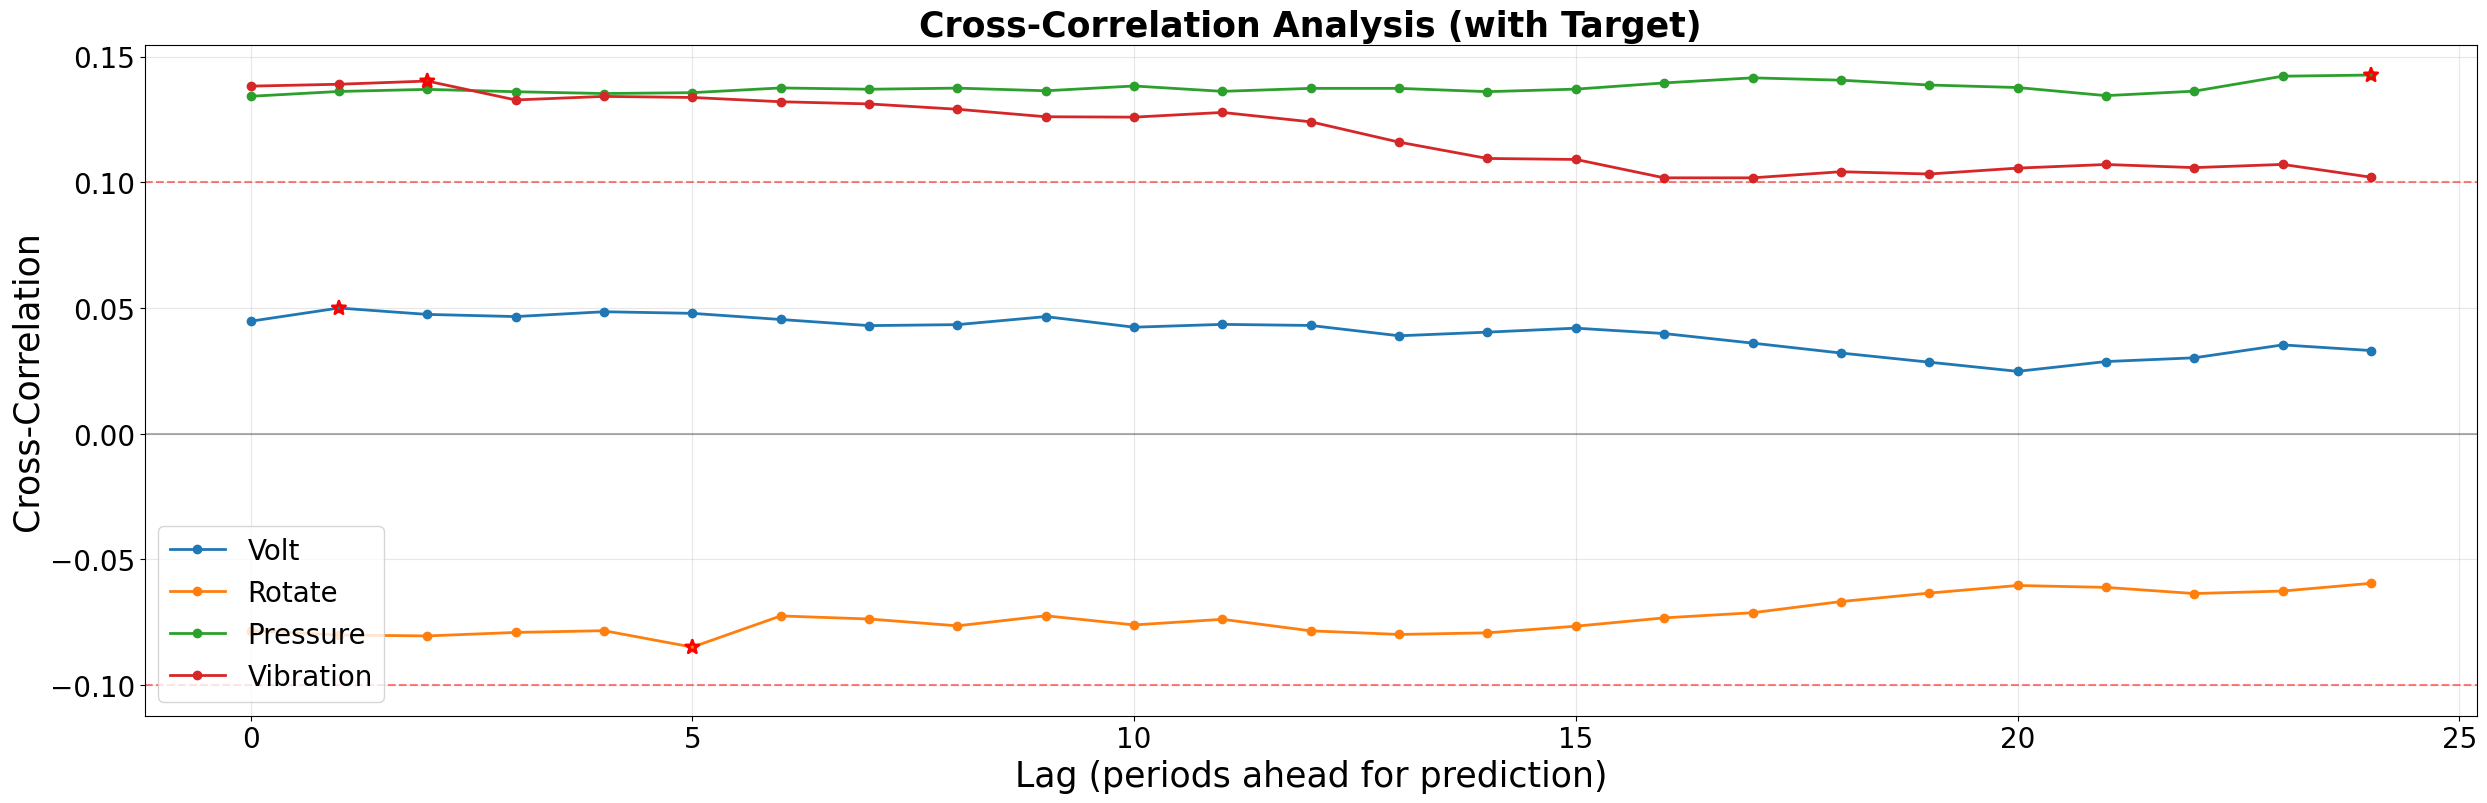

In [17]:
def cross_correlation_analysis(df, target_col='failure', sensor_cols=None, max_lag=24, plot_results=True, figsize=(25, 15), save_path=None, failure_date=None, window_hours=168):  
    
    # Validate inputs
    if sensor_cols is None:
        sensor_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                      if col not in [target_col, 'age', 'errorID', 'comp', 'model']]
    
    missing_cols = [col for col in sensor_cols if col not in df.columns]
    if missing_cols or target_col not in df.columns:
        return None
    
    # Filter data around specific failure date if provided
    if failure_date is not None:
        failure_datetime = pd.to_datetime(failure_date)
        start_time = failure_datetime - pd.Timedelta(hours=window_hours)
        end_time = failure_datetime + pd.Timedelta(hours=window_hours)
        df_filtered = df[(df.index >= start_time) & (df.index <= end_time)].copy()
        
        if df_filtered.empty:
            print(f"Warning: No data found in window around {failure_datetime}")
            return None
        
        analysis_info = f"Analysis focused on failure at {failure_datetime.strftime('%Y-%m-%d %H:%M')}"
        analysis_info += f" (±{window_hours}h window)"
        print(analysis_info)
    else:
        df_filtered = df.copy()
        analysis_info = "Analysis on full dataset"
    
    results = {'cross_correlation': {}, 'optimal_lags': {}, 'significant_lags': {}, 'analysis_info': analysis_info}
    
    # Cross-correlation computation
    for col in sensor_cols: # for each sensor column 
        sensor_data = df_filtered[col].dropna()  # Current sensor readings. (72 hours before failure + 72 hours after failure = 144 hours total Plus potentially some boundary hours = ~150 rows) 
        target_data = df_filtered[target_col].dropna() # Failure events
        
        # Align data on common index
        common_index = sensor_data.index.intersection(target_data.index)
        sensor_aligned = sensor_data.loc[common_index]
        target_aligned = target_data.loc[common_index]
        
        if len(common_index) == 0:
            continue
        
        # Calculate cross-correlations at different lags
        cross_corr_values = []
        lags = list(range(0, max_lag + 1))
        
        # Lag-by-Lag Correlation Calculation
        for lag in lags: 
            # Lag 0: Current time correlation
            # sensor(t) vs target(t)
            if lag == 0: # Lag 0: Current time correlation
                correlation = sensor_aligned.corr(target_aligned) # sensor(t) vs target(t)
            else:
                # Lag > 0: Predictive correlation 
                # sensor(t) vs target(t + lag)
                if len(sensor_aligned) > lag: 
                    target_lagged = target_aligned.shift(-lag)  # Negative Shift - The negative shift moves the target data backward in the array, which creates a forward-looking relationship
                    correlation = sensor_aligned.corr(target_lagged)
                else:
                    correlation = 0
            cross_corr_values.append(correlation if not np.isnan(correlation) else 0)
        
        # Find optimal and significant lags
        abs_correlations = [abs(corr) for corr in cross_corr_values]
        optimal_lag_index = np.argmax(abs_correlations)
        optimal_lag = lags[optimal_lag_index]
        optimal_correlation = cross_corr_values[optimal_lag_index]
        
        significant_lags = [(lags[i], cross_corr_values[i]) 
                           for i, corr in enumerate(cross_corr_values) if abs(corr) > 0.1]
        
        # Store results
        results['cross_correlation'][col] = {
            'lags': lags,
            'correlations': cross_corr_values,
            'optimal_lag': optimal_lag,
            'optimal_correlation': optimal_correlation
        }
        results['optimal_lags'][col] = (optimal_lag, optimal_correlation)
        results['significant_lags'][col] = significant_lags
    
    # Visualization
    if plot_results:
        plt.figure(figsize=figsize)
        ax = plt.subplot(2, 1, 1)
        
        for col in sensor_cols:
            if col in results['cross_correlation']:
                data = results['cross_correlation'][col]
                ax.plot(data['lags'], data['correlations'], marker='o', 
                       label=f'{col.title()}', linewidth=2)
                
                # Mark optimal lag
                ax.scatter([data['optimal_lag']], [data['optimal_correlation']], 
                          s=100, marker='*', edgecolors='red', facecolors='none', 
                          linewidth=2, zorder=10)
        
        # Update title to show analysis focus
        title = f'Cross-Correlation Analysis (with {target_col.title()})'
        if failure_date is not None:
            title += f'\nFocused on failure: {pd.to_datetime(failure_date).strftime("%Y-%m-%d %H:%M")}'
            title += f' (±{window_hours}h window)'
        
        ax.set_title(title, fontsize=25, fontweight='bold')
        ax.set_xlabel('Lag (periods ahead for prediction)', fontsize=25)
        ax.set_ylabel('Cross-Correlation', fontsize=25)
        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=20)
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        ax.axhline(y=0.1, color='red', linestyle='--', alpha=0.5)
        ax.axhline(y=-0.1, color='red', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
    
    # Save results
    if save_path:
        # Add analysis info to filename if specific failure date is used
        filename_suffix = ""
        if failure_date is not None:
            date_str = pd.to_datetime(failure_date).strftime('%Y%m%d_%H%M')
            filename_suffix = f"_{date_str}"
        
        # Cross-correlation data
        cross_corr_df = pd.DataFrame()
        for col in sensor_cols:
            if col in results['cross_correlation']:
                temp_df = pd.DataFrame({
                    'sensor': col,
                    'lag': results['cross_correlation'][col]['lags'],
                    'correlation': results['cross_correlation'][col]['correlations']
                })
                cross_corr_df = pd.concat([cross_corr_df, temp_df], ignore_index=True)
        
        cross_corr_df.to_csv(f'{save_path}/cross_correlation_results{filename_suffix}.csv', index=False)
        
        # Optimal lags summary
        optimal_lags_df = pd.DataFrame([
            {'sensor': sensor, 'optimal_lag': lag, 'correlation': corr}
            for sensor, (lag, corr) in results['optimal_lags'].items()
        ])
        optimal_lags_df.to_csv(f'{save_path}/optimal_lags_summary{filename_suffix}.csv', index=False)
    
    return results


lag_results = cross_correlation_analysis(
    df=lag_machine_dataframes["machine_98"],
    target_col="target",
    sensor_cols=['volt', 'rotate', 'pressure', 'vibration'],
    max_lag=24,
    plot_results=True
)

🔍 STEP 1: DISCOVERING OPTIMAL LAGS WITH CROSS-CORRELATION


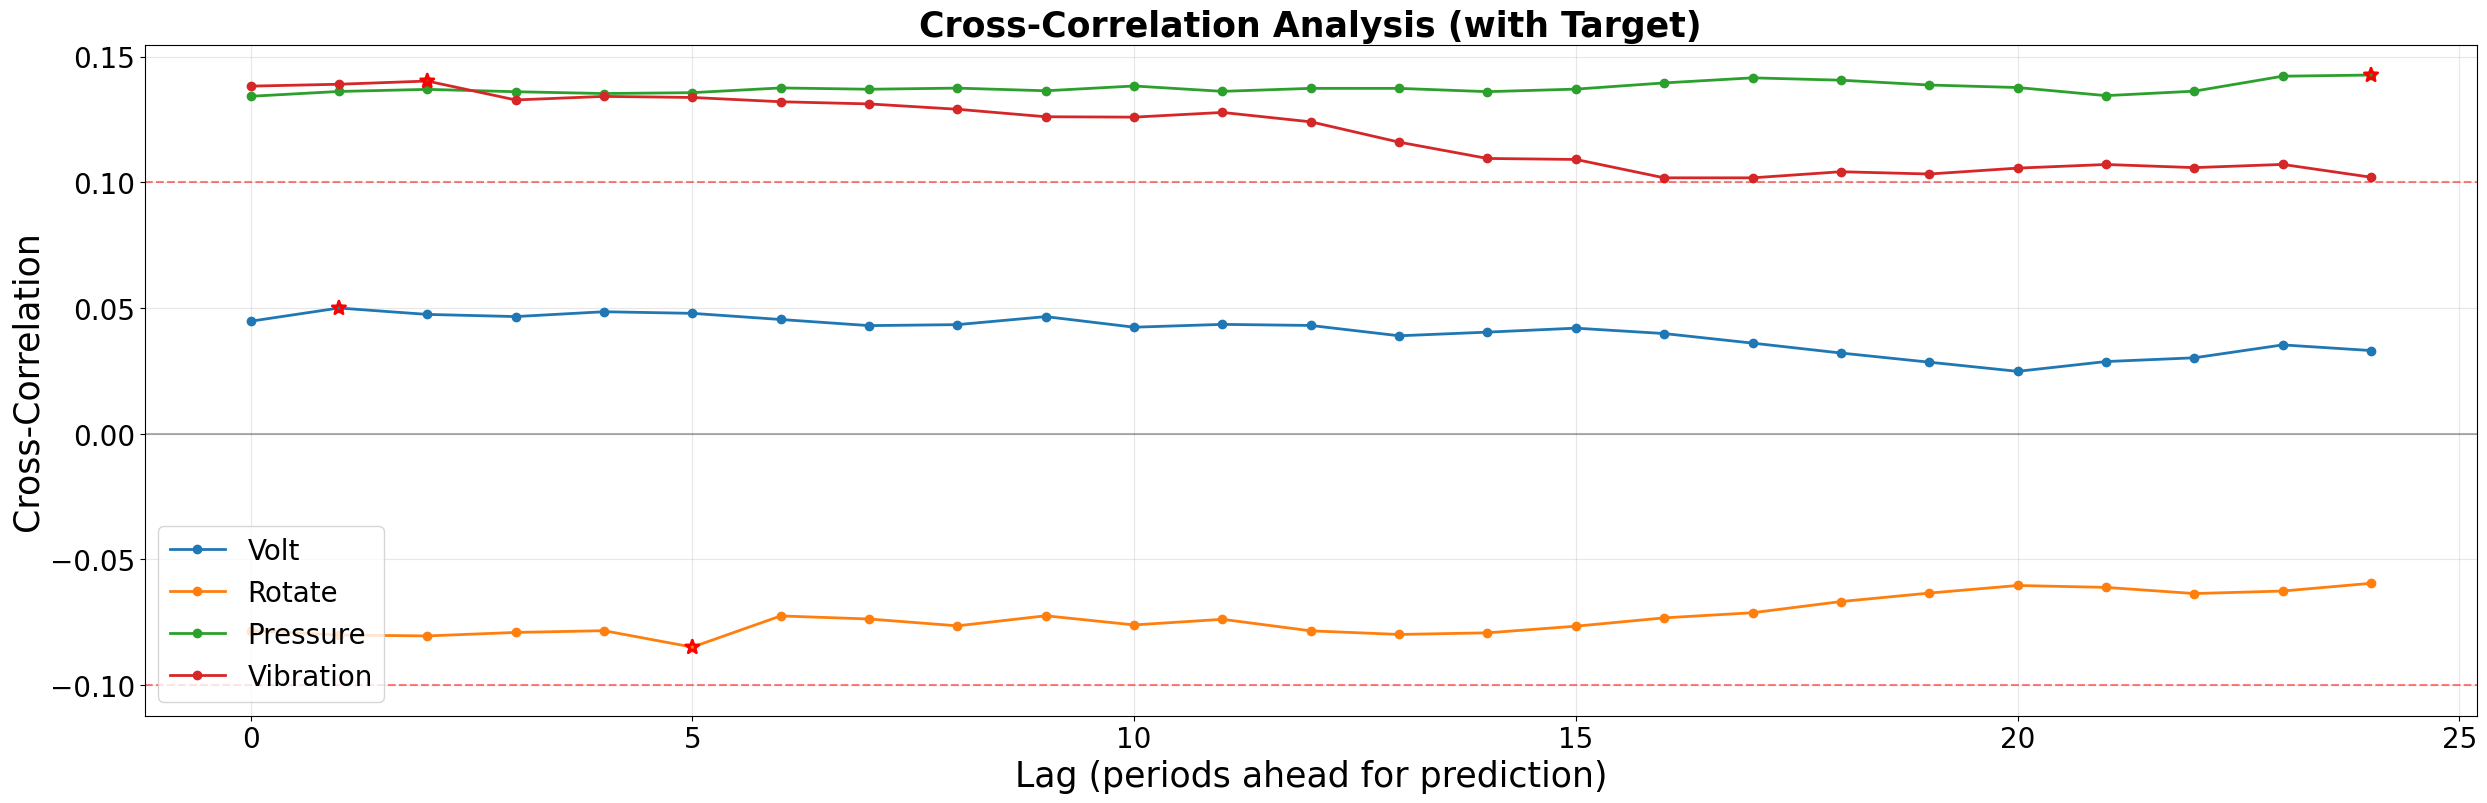

   📊 volt: optimal lag = 1h (corr = 0.050)
   📊 rotate: optimal lag = 5h (corr = -0.085)
   📊 pressure: optimal lag = 24h (corr = 0.143)
   📊 vibration: optimal lag = 2h (corr = 0.140)

🎯 Using lag=24 in VARLiNGAM (max discovered lag)

🔍 STEP 2: CAUSAL DISCOVERY WITH INFORMED LAG

📊 COMPREHENSIVE CAUSAL ANALYSIS RESULTS
Total relationships found: 200

🎯 RELATIONSHIPS TO TARGET (target):
----------------------------------------
  volt → target (strength: 0.0198, lag: 1)
  rotate → target (strength: -0.0113, lag: 1)
  pressure → target (strength: 0.0158, lag: 1)
  vibration → target (strength: 0.0312, lag: 1)
  volt → target (strength: -0.0135, lag: 2)
  rotate → target (strength: 0.0009, lag: 2)
  pressure → target (strength: -0.0054, lag: 2)
  vibration → target (strength: -0.0142, lag: 2)
  volt → target (strength: 0.0040, lag: 3)
  rotate → target (strength: -0.0000, lag: 3)
  pressure → target (strength: 0.0026, lag: 3)
  vibration → target (strength: -0.0048, lag: 3)
  volt → targe

In [18]:
def comprehensive_causal_discovery(df, target_col='failure', independent_vars=None, method='varlingam', lag=1):
    
     # ✅ CRITICAL: Ensure data is sorted by datetime index
    if not df.index.is_monotonic_increasing:
        print("⚠️ WARNING: Sorting data by datetime index for proper lag calculation")
        df = df.sort_index()
    
    # Check for missing time periods
    time_diff = df.index.to_series().diff()
    irregular_intervals = time_diff.value_counts()
    
    if len(irregular_intervals) > 1:
        print("⚠️ WARNING: Irregular time intervals detected!")
        print(f"Time intervals found: {irregular_intervals}")
        print("VARLiNGAM assumes regular intervals. Consider resampling data.")
        
    # Prepare feature list
    if independent_vars is None:
        features = [col for col in df.columns if col != target_col]
    else:
        features = independent_vars.copy()
    
    # Include target variable in the analysis
    all_variables = features + [target_col]
    
    # Prepare data with ALL variables (including target)
    X = df[all_variables].values    
    
    if method == 'varlingam':
        # Standard VARLiNGAM with optimization
        model = VARLiNGAM(
            lags=lag,  # Reduce lags to speed up computation
            criterion='bic',  # Use BIC for model selection
            prune=False,  # Enable pruning for sparsity            
        )
        
        try:
            model.fit(X)
            adjacency_matrices = model.adjacency_matrices_
        except np.linalg.LinAlgError:
            print("Adding regularization...")
            X_reg = X + np.random.normal(0, 1e-6, X.shape)
            model.fit(X_reg)
            adjacency_matrices = model.adjacency_matrices_
    
    # Convert to structured format with ALL relationships
    structured_adjacency = []
    relationships_to_target = []
    relationships_from_target = []
    inter_feature_relationships = []
    
    for lag_idx, adj_matrix in enumerate(adjacency_matrices):
        for i in range(len(all_variables)):
            for j in range(len(all_variables)):
                if adj_matrix[i, j] != 0:
                    source_var = all_variables[i]
                    target_var = all_variables[j]
                    effect_strength = adj_matrix[i, j]
                    
                    relationship = {
                        'source_feature': source_var,
                        'target_feature': target_var,
                        'effect_strength': effect_strength,
                        'lag': lag_idx,
                        'relationship_type': 'self' if source_var == target_var else 'causal'
                    }
                    
                    structured_adjacency.append(relationship)
                    
                    # Categorize relationships
                    if target_var == target_col and source_var != target_col:
                        relationships_to_target.append(relationship)
                    elif source_var == target_col and target_var != target_col:
                        relationships_from_target.append(relationship)
                    elif source_var != target_col and target_var != target_col:
                        inter_feature_relationships.append(relationship)
    
    # Print detailed summary
    print(f"\n📊 COMPREHENSIVE CAUSAL ANALYSIS RESULTS")
    print("=" * 60)
    print(f"Total relationships found: {len(structured_adjacency)}")
    
    print(f"\n🎯 RELATIONSHIPS TO TARGET ({target_col}):")
    print("-" * 40)
    if relationships_to_target:
        for rel in relationships_to_target:
            print(f"  {rel['source_feature']} → {rel['target_feature']} "
                  f"(strength: {rel['effect_strength']:.4f}, lag: {rel['lag']})")
    else:
        print("  No direct causal relationships found to target variable")
    
    print(f"\n📤 RELATIONSHIPS FROM TARGET ({target_col}):")
    print("-" * 40)
    if relationships_from_target:
        for rel in relationships_from_target:
            print(f"  {rel['source_feature']} → {rel['target_feature']} "
                  f"(strength: {rel['effect_strength']:.4f}, lag: {rel['lag']})")
    else:
        print("  Target variable does not cause other variables")
    
    print(f"\n🔄 INTER-FEATURE RELATIONSHIPS:")
    print("-" * 40)
    if inter_feature_relationships:
        for rel in inter_feature_relationships:
            print(f"  {rel['source_feature']} → {rel['target_feature']} "
                  f"(strength: {rel['effect_strength']:.4f}, lag: {rel['lag']})")
    else:
        print("  No relationships found between independent variables")
    
    return structured_adjacency

def adaptive_causal_discovery(df, target_col='failure', sensor_cols=None, max_exploration_lag=24):
    """
    Use cross-correlation to inform VARLiNGAM lag parameter
    """
    
    print("🔍 STEP 1: DISCOVERING OPTIMAL LAGS WITH CROSS-CORRELATION")
    print("=" * 60)
    
    # Discover optimal lags
    lag_results = cross_correlation_analysis(
        df=df,
        target_col=target_col,
        sensor_cols=sensor_cols,
        max_lag=max_exploration_lag,
        plot_results=True
    )
    
    # Extract optimal lags
    discovered_lags = {}
    for sensor in sensor_cols:
        if sensor in lag_results['optimal_lags']:
            optimal_lag = lag_results['optimal_lags'][sensor][0]
            correlation = lag_results['optimal_lags'][sensor][1]
            discovered_lags[sensor] = optimal_lag
            print(f"   📊 {sensor}: optimal lag = {optimal_lag}h (corr = {correlation:.3f})")
    
    # Determine VARLiNGAM lag parameter
    if discovered_lags:
        varlingam_lag = max(discovered_lags.values())
        print(f"\n🎯 Using lag={varlingam_lag} in VARLiNGAM (max discovered lag)")
    else:
        varlingam_lag = 1
        print(f"\n⚠️ No optimal lags found, using default lag=1")
    
    print("\n🔍 STEP 2: CAUSAL DISCOVERY WITH INFORMED LAG")
    print("=" * 60)
    
    # Run VARLiNGAM with discovered lag
    comprehensive_causality_results = comprehensive_causal_discovery(
        df=df,
        target_col=target_col,
        independent_vars=sensor_cols,
        method='varlingam',
        # lag=1
        lag=varlingam_lag  # ← Use discovered lag!
    )
    
    return lag_results, comprehensive_causality_results, discovered_lags, varlingam_lag

# Run the adaptive approach
lag_results, comprehensive_causality_results, discovered_lags, used_lag = adaptive_causal_discovery(
    df=lag_machine_dataframes["machine_98"],
    target_col='target',
    sensor_cols=['volt', 'rotate', 'pressure', 'vibration'],
    max_exploration_lag=24
)

🔬 ANALYZING CAUSALITY FOR MACHINE_98
✅ Found causality results with 200 relationships
🎨 DISPLAYING COMPREHENSIVE CAUSAL GRAPH
📊 Found 200 total relationships
📊 130 relationships above threshold (0.01)
📊 95 causal relationships (cross-feature)
📊 35 self-relationships (autoregressive)
📊 Features in graph: ['pressure', 'rotate', 'target', 'vibration', 'volt']
💾 Graph saved to: causal_graph_machine_98.png


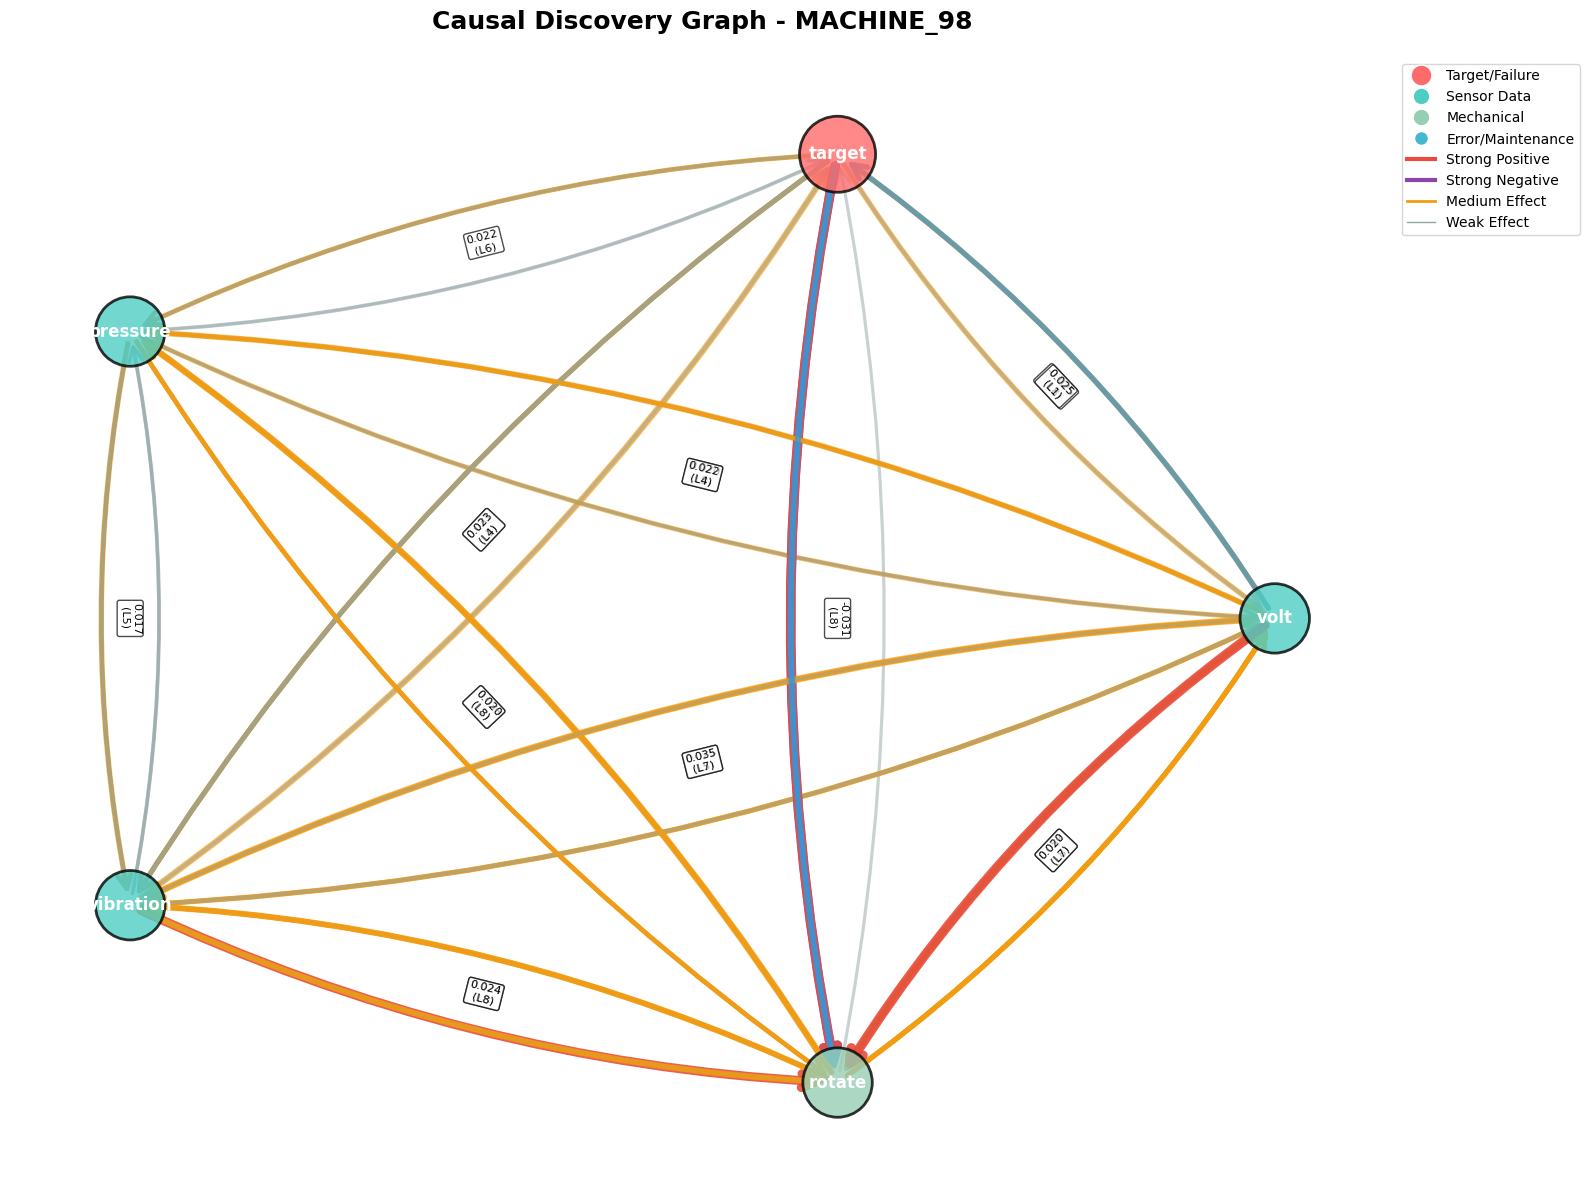


📋 DETAILED CAUSAL RELATIONSHIP ANALYSIS

LAG 1 RELATIONSHIPS:
------------------------------
 1. 🟢 volt → rotate
    Effect: 0.0332 (positive)
 2. 🟢 vibration → target
    Effect: 0.0312 (positive)
 3. 🟢 pressure → vibration
    Effect: 0.0259 (positive)
 4. 🟢 target → rotate
    Effect: -0.0250 (negative)
 5. 🟢 target → volt
    Effect: 0.0248 (positive)
 6. 🟢 rotate → volt
    Effect: 0.0224 (positive)
 7. 🟢 rotate → vibration
    Effect: 0.0214 (positive)
 8. 🟢 vibration → rotate
    Effect: 0.0213 (positive)
 9. 🟢 volt → target
    Effect: 0.0198 (positive)
10. 🟢 pressure → rotate
    Effect: 0.0198 (positive)
    ... and 9 more relationships

LAG 2 RELATIONSHIPS:
------------------------------
 1. 🟢 volt → vibration
    Effect: 0.0253 (positive)
 2. 🟢 rotate → volt
    Effect: 0.0219 (positive)
 3. 🟢 vibration → volt
    Effect: 0.0218 (positive)
 4. 🟢 target → vibration
    Effect: 0.0217 (positive)
 5. 🟢 pressure → rotate
    Effect: 0.0206 (positive)
 6. 🟢 rotate → vibration
 

In [19]:
def display_comprehensive_causal_graph(causality_results, title="Comprehensive Causal Discovery Graph", threshold=0.05, figsize=(16, 12), save_path=None):
    """
    Display and analyze the comprehensive causality results from VARLiNGAM analysis.
    
    Args:
        causality_results: List of dictionaries containing causal relationships
        title: Title for the visualization
        threshold: Minimum effect strength to display relationships
        figsize: Figure size for the plot
        save_path: Optional path to save the visualization
    
    Returns:
        dict: Summary statistics and filtered relationships
    """
    
    print("🎨 DISPLAYING COMPREHENSIVE CAUSAL GRAPH")
    print("=" * 60)
    
    if not causality_results:
        print("❌ No causality results to display")
        return None
    
    # Filter relationships by threshold
    significant_relationships = [
        rel for rel in causality_results 
        if abs(rel.get('effect_strength', 0)) > threshold
    ]
    
    # Separate relationship types
    causal_relationships = [r for r in significant_relationships if r.get('relationship_type') == 'causal']
    self_relationships = [r for r in significant_relationships if r.get('relationship_type') == 'self']
    
    print(f"📊 Found {len(causality_results)} total relationships")
    print(f"📊 {len(significant_relationships)} relationships above threshold ({threshold})")
    print(f"📊 {len(causal_relationships)} causal relationships (cross-feature)")
    print(f"📊 {len(self_relationships)} self-relationships (autoregressive)")
    
    if not significant_relationships:
        print(f"⚠️ No relationships found above threshold {threshold}")
        print("💡 Try lowering the threshold or check your data")
        return None
    
    # Create directed graph
    G = nx.DiGraph()
    
    # Get all unique features
    all_features = set()
    for rel in significant_relationships:
        all_features.add(rel['source_feature'])
        all_features.add(rel['target_feature'])
    
    print(f"📊 Features in graph: {sorted(all_features)}")
    
    # Add nodes to graph
    G.add_nodes_from(all_features)
    
    # Add edges (only causal relationships for cleaner visualization)
    edge_data = []
    for rel in causal_relationships:
        source = rel['source_feature']
        target = rel['target_feature']
        strength = rel['effect_strength']
        lag = rel.get('lag', 0)
        
        # Add edge to graph
        G.add_edge(source, target, 
                  weight=abs(strength), 
                  strength=strength, 
                  lag=lag,
                  relationship_type='causal')
        
        edge_data.append({
            'source': source,
            'target': target,
            'strength': strength,
            'abs_strength': abs(strength),
            'lag': lag
        })
    
    # Create visualization
    plt.figure(figsize=figsize)
    
    # Calculate layout
    if len(G.nodes()) > 0:
        # Use different layouts based on graph size
        if len(G.nodes()) <= 6:
            pos = nx.circular_layout(G, scale=2)
        elif len(G.nodes()) <= 10:
            pos = nx.spring_layout(G, k=3, iterations=100, seed=42)
        else:
            pos = nx.kamada_kawai_layout(G)
    else:
        pos = {}
    
    # Define node colors based on feature type
    node_colors = []
    node_sizes = []
    
    for node in G.nodes():
        # Determine node color based on feature type
        if 'target' in node.lower() or 'failure' in node.lower():
            color = '#FF6B6B'  # Red for target/failure
            size = 3000
        elif node in ['volt', 'voltage', 'pressure', 'vibration', 'temperature']:
            color = '#4ECDC4'  # Teal for sensor data
            size = 2500
        elif node in ['rotate', 'rotation', 'speed', 'rpm']:
            color = '#96CEB4'  # Green for rotation/mechanical
            size = 2500
        elif 'error' in node.lower() or 'comp' in node.lower():
            color = '#45B7D1'  # Blue for error/maintenance
            size = 2000
        else:
            color = '#FFEAA7'  # Yellow for others
            size = 2000
        
        node_colors.append(color)
        node_sizes.append(size)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, 
                          node_color=node_colors, 
                          node_size=node_sizes,
                          alpha=0.8,
                          edgecolors='black',
                          linewidths=2)
    
    # Draw node labels
    nx.draw_networkx_labels(G, pos, 
                           font_size=12, 
                           font_weight='bold',
                           font_color='white')
    
    # Draw edges with different styles based on strength and sign
    if edge_data:
        max_strength = max([abs(e['strength']) for e in edge_data])
        
        for edge_info in edge_data:
            source = edge_info['source']
            target = edge_info['target']
            strength = edge_info['strength']
            lag = edge_info['lag']
            
            # Determine edge color based on strength and direction
            if abs(strength) > max_strength * 0.7:
                edge_color = '#E74C3C' if strength > 0 else '#8E44AD'  # Strong: Red/Purple
                alpha = 0.9
            elif abs(strength) > max_strength * 0.3:
                edge_color = '#F39C12' if strength > 0 else '#3498DB'  # Medium: Orange/Blue
                alpha = 0.7
            else:
                edge_color = '#95A5A6'  # Weak: Gray
                alpha = 0.5
            
            # Edge width based on strength
            edge_width = 1 + 6 * (abs(strength) / max_strength)
            
            # Draw edge
            nx.draw_networkx_edges(G, pos,
                                 edgelist=[(source, target)],
                                 width=edge_width,
                                 alpha=alpha,
                                 edge_color=edge_color,
                                 arrows=True,
                                 arrowsize=25,
                                 arrowstyle='->',
                                 connectionstyle="arc3,rad=0.1")
        
        # Add edge labels with strength and lag
        edge_labels = {}
        for edge_info in edge_data:
            source = edge_info['source']
            target = edge_info['target']
            strength = edge_info['strength']
            lag = edge_info['lag']
            
            # Only show labels for stronger relationships to avoid clutter
            if abs(strength) > max_strength * 0.3:
                lag_text = f"L{lag}" if lag > 0 else "Inst"
                edge_labels[(source, target)] = f"{strength:.3f}\n({lag_text})"
        
        # Draw edge labels
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8, bbox=dict(boxstyle="round,pad=0.2", 
                                                                                 facecolor="white", 
                                                                                 alpha=0.7))
    
    # Create legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF6B6B', markersize=15, label='Target/Failure'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#4ECDC4', markersize=12, label='Sensor Data'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#96CEB4', markersize=12, label='Mechanical'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#45B7D1', markersize=10, label='Error/Maintenance'),
        plt.Line2D([0], [0], color='#E74C3C', linewidth=3, label='Strong Positive'),
        plt.Line2D([0], [0], color='#8E44AD', linewidth=3, label='Strong Negative'),
        plt.Line2D([0], [0], color='#F39C12', linewidth=2, label='Medium Effect'),
        plt.Line2D([0], [0], color='#95A5A6', linewidth=1, label='Weak Effect')
    ]
    
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    
    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Graph saved to: {save_path}")
    
    plt.show()
    
    # Print detailed analysis
    print("\n📋 DETAILED CAUSAL RELATIONSHIP ANALYSIS")
    print("=" * 60)
    
    # Group relationships by lag
    relationships_by_lag = {}
    for rel in causal_relationships:
        lag = rel.get('lag', 0)
        if lag not in relationships_by_lag:
            relationships_by_lag[lag] = []
        relationships_by_lag[lag].append(rel)
    
    # Display relationships by lag
    for lag in sorted(relationships_by_lag.keys()):
        lag_title = f"LAG {lag}" if lag > 0 else "INSTANTANEOUS"
        print(f"\n{lag_title} RELATIONSHIPS:")
        print("-" * 30)
        
        # Sort by absolute strength
        lag_relationships = sorted(relationships_by_lag[lag], 
                                 key=lambda x: abs(x['effect_strength']), 
                                 reverse=True)
        
        for i, rel in enumerate(lag_relationships, 1):
            strength = rel['effect_strength']
            effect_type = "positive" if strength > 0 else "negative"
            strength_indicator = "🔴" if abs(strength) > 0.5 else "🟡" if abs(strength) > 0.1 else "🟢"
            
            print(f"{i:2d}. {strength_indicator} {rel['source_feature']} → {rel['target_feature']}")
            print(f"    Effect: {strength:.4f} ({effect_type})")
            if i >= 10:  # Limit output
                remaining = len(lag_relationships) - 10
                if remaining > 0:
                    print(f"    ... and {remaining} more relationships")
                break
    
    # Summary statistics
    if causal_relationships:
        strengths = [abs(r['effect_strength']) for r in causal_relationships]
        print(f"\n📊 STRENGTH STATISTICS:")
        print(f"   Mean absolute effect: {np.mean(strengths):.4f}")
        print(f"   Max absolute effect:  {np.max(strengths):.4f}")
        print(f"   Min absolute effect:  {np.min(strengths):.4f}")
        print(f"   Std absolute effect:  {np.std(strengths):.4f}")
    
    # Return summary
    summary = {
        'total_relationships': len(causality_results),
        'significant_relationships': len(significant_relationships),
        'causal_relationships': len(causal_relationships),
        'self_relationships': len(self_relationships),
        'features': sorted(all_features),
        'relationships_by_lag': relationships_by_lag,
        'threshold_used': threshold
    }
    
    return summary

# Usage example with your data
def analyze_machine_causality(machine_name='machine_98'):
    """
    Analyze causality for a specific machine and display comprehensive graph.
    """
    
    print(f"🔬 ANALYZING CAUSALITY FOR {machine_name.upper()}")
    print("=" * 60)
    
    # Check if we have the causality results
    if 'comprehensive_causality_results' in globals():
        print(f"✅ Found causality results with {len(comprehensive_causality_results)} relationships")
        
        # Display the comprehensive graph
        summary = display_comprehensive_causal_graph(
            causality_results=comprehensive_causality_results,
            title=f"Causal Discovery Graph - {machine_name.upper()}",
            threshold=0.01,  # Adjust threshold as needed
            figsize=(16, 12),
            save_path=f"causal_graph_{machine_name}.png"  # Optional: save the graph
        )
        
        return summary
    else:
        print("❌ No causality results found. Please run the causal discovery analysis first.")
        return None


# Run the analysis
summary = analyze_machine_causality('machine_98')

# Optional: Display additional insights
if summary:
    print(f"\n🎯 KEY INSIGHTS:")
    print(f"   • {summary['causal_relationships']} causal relationships discovered")
    print(f"   • {len(summary['features'])} features analyzed")
    print(f"   • {len(summary['relationships_by_lag'])} different time lags detected")
    
    # Find most influential features
    source_counts = {}
    target_counts = {}
    
    for lag_rels in summary['relationships_by_lag'].values():
        for rel in lag_rels:
            source = rel['source_feature']
            target = rel['target_feature']
            
            source_counts[source] = source_counts.get(source, 0) + 1
            target_counts[target] = target_counts.get(target, 0) + 1
    
    if source_counts:
        most_influential = max(source_counts, key=source_counts.get)
        most_affected = max(target_counts, key=target_counts.get)
        
        print(f"   • Most influential feature: {most_influential} ({source_counts[most_influential]} outgoing)")
        print(f"   • Most affected feature: {most_affected} ({target_counts[most_affected]} incoming)")

<br> <br> 


### Find uncertain predictoins

In [ ]:
def find_most_uncertain_predictions(model_dict, data, n_uncertain=20, uncertainty_method='entropy'):
    """
    Find the most uncertain data points using CatBoost model predictions.
    
    Args:
        model_dict: Dictionary containing the loaded CatBoost model
        data: DataFrame with features for prediction
        n_uncertain: Number of most uncertain points to return
        uncertainty_method: 'entropy', 'margin', 'variance', or 'confidence'
    
    Returns:
        dict: Contains uncertain points, uncertainty scores, and analysis
    """
    
    print("🔍 FINDING MOST UNCERTAIN PREDICTIONS WITH CATBOOST")
    print("=" * 60)
    
    # Extract the actual model and metadata
    catboost_model = model_dict['model']
    feature_names = model_dict['feature_names']
    class_mapping = model_dict.get('class_mapping', {})
    reverse_mapping = model_dict.get('reverse_mapping', {})
    n_classes = model_dict.get('n_classes', 2)
    is_binary = model_dict.get('is_binary', False)
    
    print(f"📊 Model info:")
    print(f"   - Classes: {n_classes}")
    print(f"   - Binary classification: {is_binary}")
    print(f"   - Features: {len(feature_names)}")
    print(f"   - Class mapping: {class_mapping}")
    
    # Prepare features for prediction
    exclude_cols = ['datetime', 'machineID', 'failure', 'target']
    available_features = [col for col in feature_names if col in data.columns]
    missing_features = [col for col in feature_names if col not in data.columns]
    
    if missing_features:
        print(f"⚠️ Missing features: {missing_features[:5]}{'...' if len(missing_features) > 5 else ''}")
    
    print(f"✅ Using {len(available_features)} features for prediction")
    
    # Prepare prediction data
    X_predict = data[available_features].fillna(0)
    
    print(f"🔮 Making predictions on {len(X_predict)} data points...")
    
    # Get prediction probabilities
    pred_probabilities = catboost_model.predict_proba(X_predict)
    predictions = catboost_model.predict(X_predict)
    
    # Calculate uncertainty scores based on method
    if uncertainty_method == 'entropy':
        # Shannon entropy: higher values = more uncertain
        epsilon = 1e-10  # Avoid log(0)
        uncertainty_scores = -np.sum(pred_probabilities * np.log(pred_probabilities + epsilon), axis=1)
        uncertainty_name = "Entropy"
        higher_is_uncertain = True
        
    elif uncertainty_method == 'margin':
        # Margin: difference between top 2 predictions (lower = more uncertain)
        if n_classes > 1:
            sorted_probs = np.sort(pred_probabilities, axis=1)
            uncertainty_scores = sorted_probs[:, -1] - sorted_probs[:, -2]  # Top - Second best
        else:
            uncertainty_scores = np.abs(pred_probabilities[:, 0] - 0.5)  # Distance from 0.5
        uncertainty_name = "Margin"
        higher_is_uncertain = False
        
    elif uncertainty_method == 'confidence':
        # Max probability: higher = more confident (lower = more uncertain)
        uncertainty_scores = np.max(pred_probabilities, axis=1)
        uncertainty_name = "Confidence"
        higher_is_uncertain = False
        
    elif uncertainty_method == 'variance':
        # Variance of probabilities
        uncertainty_scores = np.var(pred_probabilities, axis=1)
        uncertainty_name = "Variance"
        higher_is_uncertain = True
    
    print(f"📈 Uncertainty method: {uncertainty_name}")
    print(f"   Range: {uncertainty_scores.min():.4f} - {uncertainty_scores.max():.4f}")
    print(f"   Mean: {uncertainty_scores.mean():.4f}")
    
    # Find most uncertain points
    if higher_is_uncertain:
        uncertain_indices = np.argsort(uncertainty_scores)[-n_uncertain:][::-1]  # Highest scores
    else:
        uncertain_indices = np.argsort(uncertainty_scores)[:n_uncertain]  # Lowest scores
    
    # Create results dataframe
    uncertain_data = []
    
    for i, idx in enumerate(uncertain_indices):
        # Get prediction details
        pred_proba = pred_probabilities[idx]
        prediction = int(predictions[idx][0])  # FIX: Extract scalar from array
        uncertainty = uncertainty_scores[idx]
        
        # Map prediction back to original class if needed
        if reverse_mapping:
            original_prediction = reverse_mapping.get(prediction, prediction)
        else:
            original_prediction = prediction
        
        # Get actual target if available
        actual_target = data.iloc[idx]['target'] if 'target' in data.columns else 'Unknown'
        if reverse_mapping and actual_target != 'Unknown':
            original_actual = reverse_mapping.get(int(actual_target), actual_target)
        else:
            original_actual = actual_target
        
        # Create probability distribution string
        if is_binary:
            prob_str = f"Class 0: {pred_proba[0]:.3f}, Class 1: {pred_proba[1]:.3f}"
        else:
            prob_str = ", ".join([f"Class {j}: {pred_proba[j]:.3f}" for j in range(len(pred_proba))])
        
        uncertain_point = {
            'rank': i + 1,
            'data_index': idx,
            'uncertainty_score': uncertainty,
            'predicted_class': original_prediction,
            'actual_class': original_actual,
            'prediction_correct': original_prediction == original_actual if original_actual != 'Unknown' else 'Unknown',
            'probabilities': prob_str,
            'max_probability': np.max(pred_proba),
            'datetime': data.iloc[idx]['datetime'] if 'datetime' in data.columns else 'Unknown'
        }
        
        # Add key feature values
        for feature in ['volt', 'rotate', 'pressure', 'vibration']:
            if feature in data.columns:
                uncertain_point[f'{feature}_value'] = data.iloc[idx][feature]
        
        uncertain_data.append(uncertain_point)
    
    uncertain_df = pd.DataFrame(uncertain_data)
    
    # Print summary
    print(f"\n📋 TOP {n_uncertain} MOST UNCERTAIN PREDICTIONS:")
    print("-" * 80)
    
    for _, row in uncertain_df.head(10).iterrows():  # Show top 10
        print(f"{row['rank']:2d}. Index {row['data_index']:4d} | "
              f"{uncertainty_name}: {row['uncertainty_score']:.4f} | "
              f"Pred: {row['predicted_class']} | Actual: {row['actual_class']} | "
              f"Max Prob: {row['max_probability']:.3f}")
        if 'datetime' in row and row['datetime'] != 'Unknown':
            print(f"    📅 Time: {row['datetime']}")
        print(f"    🎯 {row['probabilities']}")
        
        # Show sensor values
        sensor_values = []
        for sensor in ['volt', 'rotate', 'pressure', 'vibration']:
            if f'{sensor}_value' in row:
                sensor_values.append(f"{sensor}: {row[f'{sensor}_value']:.3f}")
        if sensor_values:
            print(f"    📊 Sensors: {', '.join(sensor_values)}")
        print()
    
    if len(uncertain_df) > 10:
        print(f"... and {len(uncertain_df) - 10} more uncertain points")
    
    # Analysis
    if 'prediction_correct' in uncertain_df.columns:
        correct_predictions = uncertain_df['prediction_correct'] == True
        incorrect_predictions = uncertain_df['prediction_correct'] == False
        
        print(f"\n📊 UNCERTAINTY ANALYSIS:")
        print(f"   Correct predictions: {correct_predictions.sum()}/{len(uncertain_df)} "
              f"({correct_predictions.mean()*100:.1f}%)")
        print(f"   Incorrect predictions: {incorrect_predictions.sum()}/{len(uncertain_df)} "
              f"({incorrect_predictions.mean()*100:.1f}%)")
    
    # Class distribution in uncertain predictions
    class_dist = uncertain_df['predicted_class'].value_counts()
    print(f"\n📊 CLASS DISTRIBUTION IN UNCERTAIN PREDICTIONS:")
    for class_val, count in class_dist.items():
        print(f"   Class {class_val}: {count} predictions ({count/len(uncertain_df)*100:.1f}%)")
    
    # Visualize uncertainty distribution
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Uncertainty score distribution
    plt.subplot(2, 2, 1)
    plt.hist(uncertainty_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(uncertainty_scores[uncertain_indices].min(), color='red', linestyle='--', 
                label=f'Top {n_uncertain} threshold')
    plt.xlabel(f'{uncertainty_name} Score')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {uncertainty_name} Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Uncertainty vs Max Probability
    plt.subplot(2, 2, 2)
    max_probs = np.max(pred_probabilities, axis=1)
    plt.scatter(max_probs, uncertainty_scores, alpha=0.6, c='lightblue', s=20)
    plt.scatter(max_probs[uncertain_indices], uncertainty_scores[uncertain_indices], 
                c='red', s=50, alpha=0.8, label=f'Top {n_uncertain} uncertain')
    plt.xlabel('Max Probability')
    plt.ylabel(f'{uncertainty_name} Score')
    plt.title(f'{uncertainty_name} vs Confidence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Uncertain predictions over time (if datetime available)
    if 'datetime' in data.columns:
        plt.subplot(2, 2, 3)
        uncertain_times = data.iloc[uncertain_indices]['datetime']
        uncertain_scores_subset = uncertainty_scores[uncertain_indices]
        
        # Convert to datetime if string
        if uncertain_times.dtype == 'object':
            uncertain_times = pd.to_datetime(uncertain_times)
        
        plt.scatter(uncertain_times, uncertain_scores_subset, c='red', alpha=0.7)
        plt.xlabel('DateTime')
        plt.ylabel(f'{uncertainty_name} Score')
        plt.title('Uncertain Predictions Over Time')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
    
    # Plot 4: Class probabilities for most uncertain points
    plt.subplot(2, 2, 4)
    if len(uncertain_indices) > 0:
        top_uncertain_probs = pred_probabilities[uncertain_indices[:10]]  # Top 10
        
        if is_binary:
            x_pos = np.arange(len(top_uncertain_probs))
            plt.bar(x_pos - 0.2, top_uncertain_probs[:, 0], 0.4, label='Class 0', alpha=0.7)
            plt.bar(x_pos + 0.2, top_uncertain_probs[:, 1], 0.4, label='Class 1', alpha=0.7)
            plt.xlabel('Top Uncertain Predictions (Rank)')
            plt.ylabel('Probability')
            plt.title('Class Probabilities for Most Uncertain Predictions')
            plt.legend()
            plt.xticks(x_pos, [f'{i+1}' for i in range(len(top_uncertain_probs))])
        else:
            # For multiclass, show as stacked bar
            bottom = np.zeros(len(top_uncertain_probs))
            for class_idx in range(n_classes):
                plt.bar(range(len(top_uncertain_probs)), top_uncertain_probs[:, class_idx], 
                       bottom=bottom, label=f'Class {class_idx}', alpha=0.7)
                bottom += top_uncertain_probs[:, class_idx]
            plt.xlabel('Top Uncertain Predictions (Rank)')
            plt.ylabel('Probability')
            plt.title('Class Probabilities for Most Uncertain Predictions')
            plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Return comprehensive results
    results = {
        'uncertain_dataframe': uncertain_df,
        'uncertainty_scores': uncertainty_scores.tolist(),
        'uncertain_indices': uncertain_indices.tolist(),
        'predictions': predictions.tolist(),
        'probabilities': pred_probabilities.tolist(),
        'method_used': uncertainty_method,
        'model_info': {
            'n_classes': n_classes,
            'is_binary': is_binary,
            'features_used': available_features,
            'class_mapping': class_mapping
        }
    }
    
    return results

# Re-run the analysis with the fixed function
print("🎯 ANALYZING UNCERTAINTY WITH MULTIPLE METHODS (FIXED)")
print("=" * 70)

# Method 1: Entropy (most common for uncertainty)
entropy_results = find_most_uncertain_predictions(
    model_dict=catboost_model,
    data=lag_machine_dataframes["machine_98"],
    n_uncertain=20,
    uncertainty_method='entropy'
)

print("\n" + "="*70)

# Method 2: Prediction margin
margin_results = find_most_uncertain_predictions(
    model_dict=catboost_model,
    data=lag_machine_dataframes["machine_98"],
    n_uncertain=20,
    uncertainty_method='margin'
)

print("\n" + "="*70)

# Method 3: Confidence (inverse uncertainty)
confidence_results = find_most_uncertain_predictions(
    model_dict=catboost_model,
    data=lag_machine_dataframes["machine_98"],
    n_uncertain=20,
    uncertainty_method='confidence'
)

# Compare methods - FIXED VERSION
print("\n🔍 COMPARING UNCERTAINTY METHODS")
print("=" * 50)

# Check overlap between methods
entropy_indices = set(entropy_results['uncertain_indices'])
margin_indices = set(margin_results['uncertain_indices'])
confidence_indices = set(confidence_results['uncertain_indices'])

entropy_margin_overlap = len(entropy_indices & margin_indices)
entropy_confidence_overlap = len(entropy_indices & confidence_indices)
margin_confidence_overlap = len(margin_indices & confidence_indices)
all_three_overlap = len(entropy_indices & margin_indices & confidence_indices)

print(f"📊 Method Overlaps (top 20 uncertain points):")
print(f"   Entropy ∩ Margin: {entropy_margin_overlap}/20 ({entropy_margin_overlap/20*100:.1f}%)")
print(f"   Entropy ∩ Confidence: {entropy_confidence_overlap}/20 ({entropy_confidence_overlap/20*100:.1f}%)")
print(f"   Margin ∩ Confidence: {margin_confidence_overlap}/20 ({margin_confidence_overlap/20*100:.1f}%)")
print(f"   All three methods: {all_three_overlap}/20 ({all_three_overlap/20*100:.1f}%)")

# Show consensus uncertain points
consensus_indices = list(entropy_indices & margin_indices & confidence_indices)
if consensus_indices:
    print(f"\n🎯 CONSENSUS MOST UNCERTAIN POINTS (all 3 methods agree):")
    print("-" * 60)
    
    for i, idx in enumerate(consensus_indices[:5]):  # Show top 5 consensus
        row = lag_machine_dataframes["machine_98"].iloc[idx]
        print(f"{i+1}. Index {idx} | Target: {row['target']} | Time: {row.get('datetime', 'Unknown')}")
        # Show sensor values
        sensors = ['volt', 'rotate', 'pressure', 'vibration']
        sensor_vals = [f"{s}: {row[s]:.3f}" for s in sensors if s in row]
        print(f"   📊 {', '.join(sensor_vals)}")
else:
    print(f"\n⚠️ No consensus points found - methods disagree on most uncertain predictions")

<br> <br> 

### Find uncertain predictions without extra visualizations

In [ ]:
def comprehensive_uncertainty_and_causality_analysis(dataset, ml_model, uncertainty_method='entropy', num_samples_per_failure=10):
    """
    Comprehensive analysis that combines uncertainty prediction and causal discovery.
    
    Args:
        dataset (pd.DataFrame): Raw dataset for analysis
        ml_model (dict): Single trained ML model dictionary
        uncertainty_method (str): Method for uncertainty calculation ('entropy', 'margin', 'confidence', 'variance')
        num_samples_per_failure (int): Number of uncertain samples to extract per failure type
    
    Returns:
        dict: Contains uncertain dataframe and causal graph in JSON format
    """
    
    print("🔬 COMPREHENSIVE UNCERTAINTY & CAUSALITY ANALYSIS")
    print("=" * 70)
    print(f"📊 Dataset shape: {dataset.shape}")
    print(f"🤖 Model: Single ML model")
    print(f"📈 Uncertainty method: {uncertainty_method}")
    print(f"🎯 Samples per failure type: {num_samples_per_failure}")
    
    # STEP 1: ENCODE AND SCALE DATASET
    print("\n1️⃣ ENCODING AND SCALING DATASET")
    print("-" * 40)
    
    try:
        processed_df, encoders, scaler = encode_and_scale_dataframe(
            df=dataset,
            target_column='failure',
            categorical_cols=['errorID', 'comp'],
            numerical_cols=['volt', 'rotate', 'pressure', 'vibration'],
            scaling_method='minmax',
            exclude_features=['machineID', "age", "model"],
            remove_excluded=True
        )
        print("✅ Dataset encoding and scaling completed successfully")
    except Exception as e:
        print(f"❌ Error in encoding/scaling: {str(e)}")
        return None
    
    # STEP 2: CREATE LAG FEATURES
    print("\n2️⃣ CREATING LAG FEATURES")
    print("-" * 40)
    
    try:
        # Add datetime back for lag feature creation
        processed_df_with_datetime = processed_df.copy()
        processed_df_with_datetime['datetime'] = dataset['datetime'].values
        processed_df_with_datetime['datetime'] = pd.to_datetime(processed_df_with_datetime['datetime'])
        
        # Create lag features
        lag_df = create_lag_features(
            df=processed_df_with_datetime,
            target_col='failure',
            prediction_horizon=24
        )
        print("✅ Lag features created successfully")
        
    except Exception as e:
        print(f"❌ Error in lag feature creation: {str(e)}")
        return None
    
    # STEP 3: FIND MOST UNCERTAIN PREDICTIONS FOR NON-ZERO TARGETS
    print("\n3️⃣ FINDING UNCERTAIN PREDICTIONS FOR FAILURE CASES")
    print("-" * 40)
    
    # Filter data where target is not 0 (failure cases only)
    failure_data = lag_df[lag_df['target'] != 0].copy()
    print(f"📊 Failure cases found: {len(failure_data)} out of {len(lag_df)} total samples")
    
    if len(failure_data) == 0:
        print("❌ No failure cases found in the dataset")
        return None
    
    # Get unique failure types
    failure_types = failure_data['target'].unique()
    print(f"🎯 Failure types detected: {sorted(failure_types)}")
    
    try:
        # Find uncertain predictions on failure data only
        uncertain_results = find_most_uncertain_predictions_no_viz(
            model_dict=ml_model,
            data=failure_data,
            n_uncertain=min(len(failure_data), num_samples_per_failure * len(failure_types)),
            uncertainty_method=uncertainty_method
        )
        
        # Extract uncertain samples
        uncertain_df = uncertain_results['uncertain_dataframe'].copy()
        uncertain_df['uncertainty_method'] = uncertainty_method
        
        # Sample per failure type
        sampled_uncertain = []
        for failure_type in failure_types:
            failure_type_samples = uncertain_df[
                uncertain_df['actual_class'] == failure_type
            ].head(num_samples_per_failure)
            
            if len(failure_type_samples) > 0:
                sampled_uncertain.append(failure_type_samples)
                print(f"   📋 Failure type {failure_type}: {len(failure_type_samples)} uncertain samples")
        
        if sampled_uncertain:
            final_uncertain_df = pd.concat(sampled_uncertain, ignore_index=True)
            # Remove duplicates based on data_index, keeping the most uncertain
            final_uncertain_df = final_uncertain_df.sort_values('uncertainty_score', ascending=False)
            final_uncertain_df = final_uncertain_df.drop_duplicates(subset=['data_index'], keep='first')
        else:
            print("❌ No uncertain samples found")
            return None
            
    except Exception as e:
        print(f"❌ Error processing uncertainty analysis: {str(e)}")
        return None
    
    # STEP 4: CAUSAL DISCOVERY ON FULL DATASET
    print("\n4️⃣ CAUSAL DISCOVERY ANALYSIS")
    print("-" * 40)
    
    try:
        # Run causal discovery on the full lag dataset
        causal_results = comprehensive_causal_discovery(
            df=lag_df,
            target_col='target',
            independent_vars=['volt', 'rotate', 'pressure', 'vibration'],
            method='varlingam',
            lag=1
        )
        
        print("✅ Causal discovery completed successfully")
        
        # Convert causal results to JSON-serializable format
        causal_graph_json = {
            'nodes': [],
            'edges': [],
            'metadata': {
                'total_relationships': len(causal_results),
                'analysis_method': 'VARLiNGAM',
                'target_variable': 'target',
                'sensor_variables': ['volt', 'rotate', 'pressure', 'vibration']
            }
        }
        
        # Extract unique nodes
        unique_nodes = set()
        for rel in causal_results:
            unique_nodes.add(rel['source_feature'])
            unique_nodes.add(rel['target_feature'])
        
        # Add nodes to JSON
        for node in sorted(unique_nodes):
            node_info = {
                'id': node,
                'label': node,
                'type': 'target' if node == 'target' else 'sensor' if node in ['volt', 'rotate', 'pressure', 'vibration'] else 'other'
            }
            causal_graph_json['nodes'].append(node_info)
        
        # Add edges to JSON
        for rel in causal_results:
            edge_info = {
                'source': rel['source_feature'],
                'target': rel['target_feature'],
                'weight': float(rel['effect_strength']),
                'lag': int(rel['lag']),
                'relationship_type': rel['relationship_type'],
                'effect_direction': 'positive' if rel['effect_strength'] > 0 else 'negative'
            }
            causal_graph_json['edges'].append(edge_info)
        
        # Add summary statistics
        if causal_results:
            strengths = [abs(rel['effect_strength']) for rel in causal_results]
            causal_graph_json['metadata']['statistics'] = {
                'mean_effect_strength': float(np.mean(strengths)),
                'max_effect_strength': float(np.max(strengths)),
                'min_effect_strength': float(np.min(strengths)),
                'total_edges': len(causal_results)
            }
        
        print(f"📊 Causal graph summary:")
        print(f"   Nodes: {len(causal_graph_json['nodes'])}")
        print(f"   Edges: {len(causal_graph_json['edges'])}")
        
    except Exception as e:
        print(f"❌ Error in causal discovery: {str(e)}")
        causal_graph_json = None
    
    # STEP 5: ENHANCE UNCERTAIN DATAFRAME WITH ORIGINAL DATA
    print("\n5️⃣ ENHANCING UNCERTAIN DATAFRAME")
    print("-" * 40)
    
    try:
        # Add original sensor values and more context to uncertain samples
        enhanced_uncertain_df = final_uncertain_df.copy()
        
        # Map back to original indices and add original sensor values
        for idx, row in enhanced_uncertain_df.iterrows():
            original_idx = row['data_index']
            
            # Add original sensor values from the lag dataframe
            original_row = failure_data.iloc[original_idx]
            
            # Add temporal context
            enhanced_uncertain_df.loc[idx, 'original_datetime'] = original_row['datetime']
            enhanced_uncertain_df.loc[idx, 'hour_of_day'] = original_row.get('hour', 'Unknown')
            enhanced_uncertain_df.loc[idx, 'day_of_week'] = original_row.get('day_of_week', 'Unknown')
            enhanced_uncertain_df.loc[idx, 'is_weekend'] = original_row.get('is_weekend', 'Unknown')
            
            # Add lag features for context
            for sensor in ['volt', 'rotate', 'pressure', 'vibration']:
                for lag in [1, 6, 12, 24]:
                    lag_col = f'{sensor}_lag_{lag}h'
                    if lag_col in original_row:
                        enhanced_uncertain_df.loc[idx, lag_col] = original_row[lag_col]
                
                # Add rolling statistics
                for stat in ['mean', 'std', 'min', 'max']:
                    stat_col_24h = f'{sensor}_{stat}_24h'
                    stat_col_6h = f'{sensor}_{stat}_6h'
                    if stat_col_24h in original_row:
                        enhanced_uncertain_df.loc[idx, stat_col_24h] = original_row[stat_col_24h]
                    if stat_col_6h in original_row:
                        enhanced_uncertain_df.loc[idx, stat_col_6h] = original_row[stat_col_6h]
            
            # Add maintenance and error context
            enhanced_uncertain_df.loc[idx, 'hours_since_maint'] = original_row.get('hours_since_maint', 'Unknown')
            enhanced_uncertain_df.loc[idx, 'hours_since_error'] = original_row.get('hours_since_error', 'Unknown')
            enhanced_uncertain_df.loc[idx, 'error_count_24h'] = original_row.get('error_count_24h', 'Unknown')
            enhanced_uncertain_df.loc[idx, 'maint_count_24h'] = original_row.get('maint_count_24h', 'Unknown')
        
        print("✅ Uncertain dataframe enhanced with temporal and contextual features")
        
    except Exception as e:
        print(f"⚠️ Warning: Could not enhance uncertain dataframe: {str(e)}")
        enhanced_uncertain_df = final_uncertain_df
    
    # FINAL RESULTS
    print("\n🎉 ANALYSIS COMPLETED SUCCESSFULLY")
    print("=" * 70)
    print(f"📊 Final Results Summary:")
    print(f"   • Uncertain samples: {len(enhanced_uncertain_df)}")
    print(f"   • Failure types covered: {len(enhanced_uncertain_df['actual_class'].unique())}")
    print(f"   • Causal relationships: {len(causal_graph_json['edges']) if causal_graph_json else 0}")
    
    # Return results
    results = {
        'uncertain_dataframe': enhanced_uncertain_df,
        'causal_graph_json': causal_graph_json,
        'analysis_metadata': {
            'dataset_shape': dataset.shape,
            'processed_shape': lag_df.shape,
            'failure_cases': len(failure_data),
            'uncertainty_method': uncertainty_method,
            'num_samples_per_failure': num_samples_per_failure,
            'analysis_timestamp': pd.Timestamp.now().isoformat()
        },
        'encoders': encoders,
        'scaler': scaler
    }
    
    return results

def find_most_uncertain_predictions_no_viz(model_dict, data, n_uncertain=20, uncertainty_method='entropy'):
    """
    Find the most uncertain data points using ML model predictions (NO VISUALIZATION).
    
    Args:
        model_dict: Dictionary containing the loaded ML model
        data: DataFrame with features for prediction
        n_uncertain: Number of most uncertain points to return
        uncertainty_method: 'entropy', 'margin', 'variance', or 'confidence'
    
    Returns:
        dict: Contains uncertain points, uncertainty scores, and analysis
    """
    
    print("🔍 FINDING MOST UNCERTAIN PREDICTIONS")
    print("=" * 60)
    
    # Extract the actual model and metadata
    model = model_dict['model']
    feature_names = model_dict['feature_names']
    class_mapping = model_dict.get('class_mapping', {})
    reverse_mapping = model_dict.get('reverse_mapping', {})
    n_classes = model_dict.get('n_classes', 2)
    is_binary = model_dict.get('is_binary', False)
    
    print(f"📊 Model info:")
    print(f"   - Classes: {n_classes}")
    print(f"   - Binary classification: {is_binary}")
    print(f"   - Features: {len(feature_names)}")
    
    # Prepare features for prediction
    exclude_cols = ['datetime', 'machineID', 'failure', 'target']
    available_features = [col for col in feature_names if col in data.columns]
    missing_features = [col for col in feature_names if col not in data.columns]
    
    if missing_features:
        print(f"⚠️ Missing features: {len(missing_features)} features")
    
    print(f"✅ Using {len(available_features)} features for prediction")
    
    # Prepare prediction data
    X_predict = data[available_features].fillna(0)
    
    print(f"🔮 Making predictions on {len(X_predict)} data points...")
    
    # Get prediction probabilities
    pred_probabilities = model.predict_proba(X_predict)
    predictions = model.predict(X_predict)
    
    # Calculate uncertainty scores based on method
    if uncertainty_method == 'entropy':
        # Shannon entropy: higher values = more uncertain
        epsilon = 1e-10  # Avoid log(0)
        uncertainty_scores = -np.sum(pred_probabilities * np.log(pred_probabilities + epsilon), axis=1)
        uncertainty_name = "Entropy"
        higher_is_uncertain = True
        
    elif uncertainty_method == 'margin':
        # Margin: difference between top 2 predictions (lower = more uncertain)
        if n_classes > 1:
            sorted_probs = np.sort(pred_probabilities, axis=1)
            uncertainty_scores = sorted_probs[:, -1] - sorted_probs[:, -2]  # Top - Second best
        else:
            uncertainty_scores = np.abs(pred_probabilities[:, 0] - 0.5)  # Distance from 0.5
        uncertainty_name = "Margin"
        higher_is_uncertain = False
        
    elif uncertainty_method == 'confidence':
        # Max probability: higher = more confident (lower = more uncertain)
        uncertainty_scores = np.max(pred_probabilities, axis=1)
        uncertainty_name = "Confidence"
        higher_is_uncertain = False
        
    elif uncertainty_method == 'variance':
        # Variance of probabilities
        uncertainty_scores = np.var(pred_probabilities, axis=1)
        uncertainty_name = "Variance"
        higher_is_uncertain = True
    
    print(f"📈 Uncertainty method: {uncertainty_name}")
    print(f"   Range: {uncertainty_scores.min():.4f} - {uncertainty_scores.max():.4f}")
    print(f"   Mean: {uncertainty_scores.mean():.4f}")
    
    # Find most uncertain points
    if higher_is_uncertain:
        uncertain_indices = np.argsort(uncertainty_scores)[-n_uncertain:][::-1]  # Highest scores
    else:
        uncertain_indices = np.argsort(uncertainty_scores)[:n_uncertain]  # Lowest scores
    
    # Create results dataframe
    uncertain_data = []
    
    for i, idx in enumerate(uncertain_indices):
        # Get prediction details
        pred_proba = pred_probabilities[idx]
        
        # Handle prediction extraction based on type
        if isinstance(predictions[idx], (list, np.ndarray)):
            prediction = int(predictions[idx][0]) if len(predictions[idx]) > 0 else int(predictions[idx])
        else:
            prediction = int(predictions[idx])
            
        uncertainty = uncertainty_scores[idx]
        
        # Map prediction back to original class if needed
        if reverse_mapping:
            original_prediction = reverse_mapping.get(prediction, prediction)
        else:
            original_prediction = prediction
        
        # Get actual target if available
        actual_target = data.iloc[idx]['target'] if 'target' in data.columns else 'Unknown'
        if reverse_mapping and actual_target != 'Unknown':
            original_actual = reverse_mapping.get(int(actual_target), actual_target)
        else:
            original_actual = actual_target
        
        # Create probability distribution string
        if is_binary:
            prob_str = f"Class 0: {pred_proba[0]:.3f}, Class 1: {pred_proba[1]:.3f}"
        else:
            prob_str = ", ".join([f"Class {j}: {pred_proba[j]:.3f}" for j in range(len(pred_proba))])
        
        uncertain_point = {
            'rank': i + 1,
            'data_index': idx,
            'uncertainty_score': uncertainty,
            'predicted_class': original_prediction,
            'actual_class': original_actual,
            'prediction_correct': original_prediction == original_actual if original_actual != 'Unknown' else 'Unknown',
            'probabilities': prob_str,
            'max_probability': np.max(pred_proba),
            'datetime': data.iloc[idx]['datetime'] if 'datetime' in data.columns else 'Unknown'
        }
        
        # Add key feature values
        for feature in ['volt', 'rotate', 'pressure', 'vibration']:
            if feature in data.columns:
                uncertain_point[f'{feature}_value'] = data.iloc[idx][feature]
        
        uncertain_data.append(uncertain_point)
    
    uncertain_df = pd.DataFrame(uncertain_data)
    
    # Print summary
    print(f"\n📋 TOP {n_uncertain} MOST UNCERTAIN PREDICTIONS:")
    print("-" * 80)
    
    for _, row in uncertain_df.head(5).iterrows():  # Show top 5
        print(f"{row['rank']:2d}. Index {row['data_index']:4d} | "
              f"{uncertainty_name}: {row['uncertainty_score']:.4f} | "
              f"Pred: {row['predicted_class']} | Actual: {row['actual_class']}")
    
    if len(uncertain_df) > 5:
        print(f"... and {len(uncertain_df) - 5} more uncertain points")
    
    # Return comprehensive results
    results = {
        'uncertain_dataframe': uncertain_df,
        'uncertainty_scores': uncertainty_scores.tolist(),
        'uncertain_indices': uncertain_indices.tolist(),
        'predictions': predictions.tolist(),
        'probabilities': pred_probabilities.tolist(),
        'method_used': uncertainty_method,
        'model_info': {
            'n_classes': n_classes,
            'is_binary': is_binary,
            'features_used': available_features,
            'class_mapping': class_mapping
        }
    }
    
    return results

# USAGE EXAMPLE
print("🚀 RUNNING SIMPLIFIED ANALYSIS")
print("=" * 50)


machine_98_lag_features = pd.read_csv("../../data/azure_pm/lag_features/machine_98_lag_features.csv")

# Run the simplified analysis with single model
results = comprehensive_uncertainty_and_causality_analysis(
    dataset=  machine_98_lag_features,   # machine_dataframes["machine_98"],  # Use original raw dataset
    ml_model=catboost_model,  # Single model instead of dictionary
    uncertainty_method='entropy',
    num_samples_per_failure=5
)

if results:
    print("\n📋 RESULTS OVERVIEW:")
    print(f"✅ Uncertain samples extracted: {len(results['uncertain_dataframe'])}")
    print(f"✅ Causal graph nodes: {len(results['causal_graph_json']['nodes']) if results['causal_graph_json'] else 0}")
    print(f"✅ Causal graph edges: {len(results['causal_graph_json']['edges']) if results['causal_graph_json'] else 0}")
    
    # Display sample of uncertain dataframe
    print(f"\n📊 SAMPLE UNCERTAIN PREDICTIONS:")
    display_cols = ['rank', 'uncertainty_score', 'predicted_class', 'actual_class']
    print(results['uncertain_dataframe'][display_cols].head())
    
    # Display sample of causal graph
    if results['causal_graph_json']:
        print(f"\n🔗 SAMPLE CAUSAL RELATIONSHIPS:")
        for edge in results['causal_graph_json']['edges'][:5]:
            print(f"   {edge['source']} → {edge['target']} (weight: {edge['weight']:.3f}, lag: {edge['lag']})")
    
else:
    print("❌ Analysis failed - check error messages above")

In [ ]:
lag_machine_dataframes["machine_98"].head()

In [ ]:
results.keys()

In [ ]:
results["uncertain_dataframe"]

In [ ]:
# machine_dataframes["machine_98"]
results["uncertain_dataframe"].columns

In [ ]:
results["uncertain_dataframe"].iloc[0].to_frame().T

In [ ]:
lag_machine_dataframes["machine_98"]

In [21]:
def find_uncertain_rows_from_machine(machine_data, catboost_model, n_uncertain=20):
    """
    Find the most uncertain rows from machine data and return two dataframes:
    1. Enhanced dataframe with uncertainty scores and additional analysis features
    2. Original rows from the machine data without modifications
    """
    
    print(f"🔍 Finding {n_uncertain} most uncertain rows from machine data")
    print(f"📊 Machine data shape: {machine_data.shape}")
    
    # Get uncertainty analysis results
    uncertainty_results = find_most_uncertain_predictions_no_viz(
        model_dict=catboost_model,
        data=machine_data,
        n_uncertain=n_uncertain,
        uncertainty_method='entropy'
    )
    
    # Extract uncertain indices
    uncertain_indices = uncertainty_results['uncertain_indices']
    uncertain_df_enhanced = uncertainty_results['uncertain_dataframe'].copy()
    
    print(f"✅ Found {len(uncertain_indices)} uncertain predictions")
    
    # Create enhanced dataframe with uncertainty analysis
    enhanced_df = uncertain_df_enhanced.copy()
    
    # Add original feature values to enhanced dataframe
    for idx, row_idx in enumerate(uncertain_indices):
        original_row = machine_data.iloc[row_idx]
        
        # Add all original features
        for col in machine_data.columns:
            if col not in enhanced_df.columns:
                enhanced_df.loc[idx, f'original_{col}'] = original_row[col]
    
    # Create original dataframe (exact rows from machine data)
    original_uncertain_rows = machine_data.iloc[uncertain_indices].copy().reset_index(drop=True)
    
    print(f"📋 Enhanced dataframe shape: {enhanced_df.shape}")
    print(f"📋 Original rows dataframe shape: {original_uncertain_rows.shape}")
    
    # Display summary
    print(f"\n📊 UNCERTAINTY SUMMARY:")
    print(f"   • Uncertainty scores range: {enhanced_df['uncertainty_score'].min():.4f} - {enhanced_df['uncertainty_score'].max():.4f}")
    print(f"   • Average uncertainty: {enhanced_df['uncertainty_score'].mean():.4f}")
    
    if 'predicted_class' in enhanced_df.columns and 'actual_class' in enhanced_df.columns:
        print(f"   • Prediction accuracy: {(enhanced_df['predicted_class'] == enhanced_df['actual_class']).sum()}/{len(enhanced_df)}")
    
    return enhanced_df, original_uncertain_rows

# Find uncertain rows from machine_98
enhanced_uncertain, original_uncertain = find_uncertain_rows_from_machine(
    machine_data=lag_machine_dataframes["machine_98"],
    catboost_model=catboost_model,
    n_uncertain=20
)

print(f"\n🎯 RESULTS:")
print(f"Enhanced dataframe columns ({len(enhanced_uncertain.columns)}): {list(enhanced_uncertain.columns)}")
print(f"Original dataframe columns ({len(original_uncertain.columns)}): {list(original_uncertain.columns)}")

# Display sample of both dataframes
print(f"\n📋 ENHANCED DATAFRAME SAMPLE:")
display_cols = ['rank', 'uncertainty_score', 'predicted_class', 'actual_class', 'datetime']
if all(col in enhanced_uncertain.columns for col in display_cols):
    print(enhanced_uncertain[display_cols].head())

print(f"\n📋 ORIGINAL UNCERTAIN ROWS SAMPLE:")
print(original_uncertain[['datetime', 'volt', 'rotate', 'pressure', 'vibration', 'target']].head())

🔍 Finding 20 most uncertain rows from machine data
📊 Machine data shape: (8757, 65)


NameError: name 'find_most_uncertain_predictions_no_viz' is not defined

In [ ]:
# enhanced_uncertain
original_uncertain

In [ ]:
# Get the feature names from the CatBoost model
catboost_features = set(catboost_model["feature_names"])

# Get the columns from original_uncertain dataframe
original_uncertain_columns = set(original_uncertain.columns)

# Find columns that exist in original_uncertain but not in catboost model features
extra_columns = original_uncertain_columns - catboost_features

print(f"Columns in original_uncertain but not in CatBoost model features:")
print(f"Found {len(extra_columns)} extra columns:")
print(sorted(list(extra_columns)))

In [ ]:
import shap
import pandas as pd
import numpy as np

def analyze_row_with_shap(row_data, catboost_model, n_features=10):
    """
    Analyze a single row using SHAP to find the most important features for CatBoost prediction.
    
    Args:
        row_data: A pandas Series or DataFrame row from original_uncertain
        catboost_model: Dictionary containing the CatBoost model and metadata
        n_features: Number of top features to return
    
    Returns:
        dict: Contains SHAP values, feature importance, and prediction details
    """
    
    print("🔍 ANALYZING ROW WITH SHAP")
    print("=" * 50)
    
    # Extract model and metadata
    model = catboost_model['model']
    feature_names = catboost_model['feature_names']
    reverse_mapping = catboost_model.get('reverse_mapping', {})
    
    # Convert single row to DataFrame if it's a Series
    if isinstance(row_data, pd.Series):
        row_df = row_data.to_frame().T
    else:
        row_df = row_data.copy()
    
    print(f"📊 Analyzing row with datetime: {row_df['datetime'].iloc[0]}")
    print(f"🎯 Actual target: {row_df['target'].iloc[0]}")
    print(f"🔧 Model features needed: {len(feature_names)}")
    
    # Prepare features for prediction (only use features the model expects)
    available_features = [col for col in feature_names if col in row_df.columns]
    missing_features = [col for col in feature_names if col not in row_df.columns]
    
    if missing_features:
        print(f"⚠️ Missing features: {len(missing_features)} features")
        print(f"   First few missing: {missing_features[:5]}")
    
    print(f"✅ Available features: {len(available_features)}")
    
    # Extract feature values for prediction
    X_row = row_df[available_features].fillna(0)
    
    # Make prediction
    prediction_proba = model.predict_proba(X_row)
    prediction = model.predict(X_row)[0]
    
    # Map prediction back to original class
    if reverse_mapping:
        original_prediction = reverse_mapping.get(int(prediction), prediction)
    else:
        original_prediction = int(prediction)
    
    print(f"🔮 Model prediction: {original_prediction}")
    print(f"📈 Prediction probabilities: {[f'{prob:.3f}' for prob in prediction_proba[0]]}")
    
    # Initialize SHAP explainer
    print(f"\n🧠 Initializing SHAP explainer...")
    try:
        # For CatBoost, use TreeExplainer
        explainer = shap.TreeExplainer(model)
        
        # Calculate SHAP values for the single row
        shap_values = explainer.shap_values(X_row)
        
        # Get expected value (baseline)
        expected_value = explainer.expected_value
        
        print(f"✅ SHAP analysis completed")
        
    except Exception as e:
        print(f"❌ Error in SHAP analysis: {str(e)}")
        return None
    
    # Process SHAP values for multiclass
    if isinstance(shap_values, list):
        # Multiclass case - get SHAP values for the predicted class
        predicted_class_idx = int(prediction)
        shap_values_for_prediction = shap_values[predicted_class_idx][0]
        expected_val = expected_value[predicted_class_idx] if isinstance(expected_value, list) else expected_value
    else:
        # Binary case
        shap_values_for_prediction = shap_values[0]
        expected_val = expected_value
    
    # Ensure shap_values_for_prediction is 1D
    if hasattr(shap_values_for_prediction, 'shape') and len(shap_values_for_prediction.shape) > 1:
        shap_values_for_prediction = shap_values_for_prediction.flatten()
    
    # Create feature importance dataframe
    feature_importance = pd.DataFrame({
        'feature': available_features,
        'shap_value': shap_values_for_prediction,
        'feature_value': X_row.iloc[0].values,
        'abs_shap_value': np.abs(shap_values_for_prediction)
    })
    
    # Sort by absolute SHAP value
    feature_importance = feature_importance.sort_values('abs_shap_value', ascending=False)
    
    # Get top N features
    top_features = feature_importance.head(n_features)
    
    print(f"\n📋 TOP {n_features} MOST IMPORTANT FEATURES:")
    print("-" * 60)
    print(f"{'Rank':<4} {'Feature':<20} {'Value':<10} {'SHAP':<10} {'Impact'}")
    print("-" * 60)
    
    for i, (_, row) in enumerate(top_features.iterrows(), 1):
        impact = "Positive" if row['shap_value'] > 0 else "Negative"
        impact_symbol = "📈" if row['shap_value'] > 0 else "📉"
        
        print(f"{i:<4} {row['feature']:<20} {row['feature_value']:<10.3f} "
              f"{row['shap_value']:<10.3f} {impact_symbol} {impact}")
    
    # Summary statistics
    total_shap_impact = np.sum(np.abs(shap_values_for_prediction))
    top_n_impact = np.sum(top_features['abs_shap_value'])
    
    print(f"\n📊 SHAP ANALYSIS SUMMARY:")
    print(f"   Expected value (baseline): {expected_val:.3f}")
    print(f"   Total SHAP impact: {total_shap_impact:.3f}")
    print(f"   Top {n_features} features impact: {top_n_impact:.3f}")
    print(f"   Coverage by top {n_features}: {top_n_impact/total_shap_impact*100:.1f}%")
    
    # Additional context from the row
    print(f"\n🔍 ADDITIONAL ROW CONTEXT:")
    print(f"   Datetime: {row_df['datetime'].iloc[0]}")
    print(f"   Actual failure type: {row_df['target'].iloc[0]}")
    
    # Show sensor values
    sensor_features = ['volt', 'rotate', 'pressure', 'vibration']
    sensor_values = []
    for sensor in sensor_features:
        if sensor in row_df.columns:
            sensor_values.append(f"{sensor}: {row_df[sensor].iloc[0]:.3f}")
    
    if sensor_values:
        print(f"   Current sensors: {', '.join(sensor_values)}")
    
    # Show lag features for context
    lag_features = [col for col in row_df.columns if 'lag_' in col and col in top_features['feature'].values]
    if lag_features:
        print(f"   Important lag features: {', '.join(lag_features[:3])}")
    
    # Return comprehensive results
    results = {
        'prediction': {
            'predicted_class': original_prediction,
            'actual_class': int(row_df['target'].iloc[0]),
            'prediction_probabilities': prediction_proba[0].tolist(),
            'is_correct': original_prediction == int(row_df['target'].iloc[0])
        },
        'shap_analysis': {
            'expected_value': float(expected_val),
            'total_shap_impact': float(total_shap_impact),
            'top_n_coverage': float(top_n_impact/total_shap_impact*100)
        },
        'top_features': top_features.to_dict('records'),
        'all_feature_importance': feature_importance.to_dict('records'),
        'row_context': {
            'datetime': str(row_df['datetime'].iloc[0]),
            'actual_target': int(row_df['target'].iloc[0]),
            'sensor_values': {sensor: float(row_df[sensor].iloc[0]) for sensor in sensor_features if sensor in row_df.columns}
        }
    }
    
    return results

# Example usage with a random row from original_uncertain
print("🎲 ANALYZING RANDOM ROW FROM UNCERTAIN PREDICTIONS")
print("=" * 60)

# Select a random row
random_idx = np.random.randint(0, len(original_uncertain))
random_row = original_uncertain.iloc[random_idx]

print(f"📍 Selected row index: {random_idx}")
print(f"📅 Datetime: {random_row['datetime']}")
print(f"🎯 Target: {random_row['target']}")


# Analyze with SHAP
shap_results = analyze_row_with_shap(
    row_data=random_row.drop(columns=["'datetime', 'failure', 'target'"]),
    catboost_model=catboost_model,
    n_features=5
)

if shap_results:
    print(f"\n🎉 SHAP ANALYSIS COMPLETED SUCCESSFULLY")
    print(f"✅ Prediction accuracy: {'Correct' if shap_results['prediction']['is_correct'] else 'Incorrect'}")
    print(f"📈 Top features explain {shap_results['shap_analysis']['top_n_coverage']:.1f}% of the decision")